# Proteomics enrichment pipeline — ORA + GSEA

This notebook runs two complementary enrichment analyses on each proteomic and PTM dataset:

1. **ORA (Over-Representation Analysis)** — Fisher's exact test on Venn-section hit lists.
   Answers *"what's over-represented in the proteins uniquely significant under oscillation vs low oxygen vs shared?"*
2. **GSEA (preranked)** — `gseapy` with a signed `log2FC × −log10(padj)` ranking.
   Answers *"what pathways are coordinately shifting under each contrast, even without a hard significance cutoff?"*

Both pathways share the same protein/annotation infrastructure and emit publication-styled figures
(Times New Roman, large fonts, no on-figure titles, PDF + PNG).

**Workflow**:  Cell 1 (globals) → Cell 6 (load CSVs) → run Cell 7 (the loop). 

## Cell 1 — Globals

Edit-in-one-place settings: column names, significance cutoffs, plot/GSEA params, dataset list.

In [1]:
import os
import ast
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib_venn import venn2
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

from pathlib import Path
import os
import pandas as pd

# gseapy is optional — only required if RUN_GSEA = True
try:
    import gseapy as gp
    _HAS_GSEAPY = True
except ImportError:
    _HAS_GSEAPY = False

/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [16]:


# ═══════════════════════════════════════════════════════════════════
# Publication style (applies to every figure)
# ═══════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype":     42,    # editable text in Illustrator
    "ps.fonttype":      42,
    "axes.linewidth":   1.2,
    "savefig.bbox":     "tight",
})

# ═══════════════════════════════════════════════════════════════════
# DATA COLUMN NAMES
# ═══════════════════════════════════════════════════════════════════
PROTEIN_COL  = "proteinId"

LOW_FC_COL   = "low/control_late_combined"
LOW_PADJ_COL = "low/control_late_combined_ANOVA_padj"
LOW_PVAL_COL = "low/control_late_combined_ANOVA_p"

# Oscillation comparison toggle — pick one
OSC_COMPARISON = "vs_control"   # "vs_control" or "vs_low"

if OSC_COMPARISON == "vs_control":
    OSC_FC_COL   = "osc/control_late_cominbed"
    OSC_PADJ_COL = "osc/control_late_cominbedANOVA_padj"
    OSC_PVAL_COL = "osc/control_late_cominbedANOVA_p"
elif OSC_COMPARISON == "vs_low":
    OSC_FC_COL   = "osc/low_late_cominbed"
    OSC_PADJ_COL = "osc/low_late_cominbedANOVA_padj"
    OSC_PVAL_COL = "osc/low_late_cominbedANOVA_p"
else:
    raise ValueError(f"Unknown OSC_COMPARISON: {OSC_COMPARISON!r}")

# ═══════════════════════════════════════════════════════════════════
# SIGNIFICANCE FILTERING (used by ORA prep)
# ═══════════════════════════════════════════════════════════════════
PVAL_MODE        = "pval"           # "padj" or "pval"
PVAL_CUTOFF      = 0.05
LOG2FC_THRESHOLD = np.log2(1.3)     # ≈ 0.378 - standard used for TMT method.

# ═══════════════════════════════════════════════════════════════════
# ENRICHMENT / PLOT SETTINGS
# ═══════════════════════════════════════════════════════════════════
MIN_TERM_SIZE  = 3
PADJ_CUTOFF    = 0.05   # term-level FDR cutoff inside ORA plots
TOP_N_TERMS    = 10
MAX_TERM_LABEL = 55
FIG_DPI        = 600
SAVE_FIGURES   = True
SAVE_TABLES    = True

# Subset of styles to actually emit per (dataset, ann_col)
PLOT_STYLES = [
    "venn",
    "enrichment_dotplot",
    "raw_bubble",
    "enrichment_heatmap",
    "enrichment_barh",
]

# Datasets to run
DATASETS_TO_RUN = ["proteomics", "redox", "phospho"]

# Annotation handling
ANNOTATION_MODE = "all"          # "single" (use ANN_COL only) or "all" (loop)
ANN_COL         = "kogGroup"
ANNOTATION_PRIORITY = [
    "kogGroup", "kogClass", "pathway_class", "pathway", "pathway_type",
    "goName", "gotermType", "goAcc", "kogdefline", "definition",
    "catalyticActivity",
]
ANNOTATION_INCLUDE = [           # None for all, list to restrict
    "kogGroup", "kogClass", "pathway_class", "pathway", "pathway_type",
    "goName", "gotermType", "goAcc", "kogdefline", "definition",
    "catalyticActivity",
]

# Output root
OUTDIR = "enrichment_outputs"

# ═══════════════════════════════════════════════════════════════════
# GSEA (preranked) settings
# ═══════════════════════════════════════════════════════════════════
RUN_GSEA          = True
GSEA_PERMUTATIONS = 1000
GSEA_MIN_SET_SIZE = 3
GSEA_MAX_SET_SIZE = 500
GSEA_FDR_CUTOFF   = 0.25         # term-level cutoff for filtering plot
GSEA_TOP_N_EACH   = 10           # top-N up + top-N down per panel
GSEA_SAVE_RUNS    = False        # write gseapy's per-run output folders

# Optional separate annotation file for gene-set membership.
# Set to None to use the proteomics file's own annotation columns.
ANNOT_BG_FILE   = None           # e.g. "../Annotations/KOG_GO_KEGG_EC_annotations.csv"
ANNOT_BG_ID_COL = "proteinId"

# Contrasts to GSEA on — (label, FC column, padj column)
GSEA_CONTRASTS = [
    ("low",  LOW_FC_COL, LOW_PADJ_COL),
    ("osc",  OSC_FC_COL, OSC_PADJ_COL),
    # Add more by uncommenting / adding:
    # ("early_late",          "early/late",       "early/late_ANOVA_padj"),
    # ("low_late_vs_early",   "low_late/early",   "low_late/early_padj"),
]

## Cell 2 — Helper functions

Annotation parsing, gene/term collapsing, Fisher's exact enrichment, term selection.

In [17]:
def parse_terms(x):
    """Split an annotation cell into a list of terms.
    Handles list-strings, separator-delimited strings, and bare values."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(i).strip() for i in x if str(i).strip()]
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return [str(i).strip() for i in val if str(i).strip()]
        return [str(val).strip()]
    except Exception:
        pass
    for sep in [" // ", "//", " | ", "|", ";"]:
        s = s.replace(sep, ";;;")
    return [i.strip() for i in s.split(";;;") if i.strip()]
import pandas as pd

def overwrite_annotations_with_external(df, annot_path, id_col,
                                         annotation_cols=None,
                                         annot_id_col=None):
    """
    Replace embedded annotation columns in `df` (notebook 1's proteomics
    dataframe) with the corresponding columns from the external annotation
    file used in notebook 2, joined on protein ID.
    """
    annot = pd.read_csv(annot_path)
    annot_id_col = annot_id_col or id_col
    if annot_id_col not in annot.columns and "#proteinId" in annot.columns:
        annot = annot.rename(columns={"#proteinId": annot_id_col})

    def clean_ids(series):
        s = series.astype(str).str.strip()
        s = s.str.replace(r"\.0$", "", regex=True)
        return s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})

    df = df.copy()
    df[id_col] = clean_ids(df[id_col])
    annot[annot_id_col] = clean_ids(annot[annot_id_col])
    annot = annot.replace({r"^\s*\\N\s*$": pd.NA}, regex=True)

    if annotation_cols is None:
        annotation_cols = [c for c in annot.columns
                            if c != annot_id_col and c in df.columns]
    missing = [c for c in annotation_cols if c not in annot.columns]
    if missing:
        raise ValueError(f"Not in external annotation file: {missing}")

    # If the external file is long-format (one row per protein per
    # category, rather than comma-joined), collapse to one row per
    # protein with a real list in each cell -- this is what fixes the
    # "combined label" problem instead of just relocating it.
    dup_ids = annot[annot_id_col].duplicated().any()
    if dup_ids:
        print("External file has multiple rows per protein -- "
              "collapsing to list-valued cells per annotation column.")
        agg = {}
        for col in annotation_cols:
            agg[col] = annot.groupby(annot_id_col)[col].apply(
                lambda s: sorted(set(s.dropna().astype(str).str.strip()))
            )
        annot_collapsed = pd.DataFrame(agg).reset_index()
    else:
        annot_collapsed = annot[[annot_id_col] + annotation_cols].drop_duplicates(subset=annot_id_col)

    df = df.drop(columns=[c for c in annotation_cols if c in df.columns])
    df = df.merge(annot_collapsed, left_on=id_col, right_on=annot_id_col, how="left")
    if annot_id_col != id_col:
        df = df.drop(columns=[annot_id_col])

    n_missing = df[annotation_cols[0]].isna().sum()
    print(f"{n_missing} / {len(df)} proteins unmatched in external file for these columns")
    return df

def shorten_term(x, max_len=55):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 3] + "..."


def available_annotation_cols(df):
    cols = [c for c in ANNOTATION_PRIORITY if c in df.columns]
    extra = [c for c in df.columns if c not in cols and c not in {
        LOW_FC_COL, LOW_PADJ_COL, OSC_FC_COL, OSC_PADJ_COL, PROTEIN_COL
    }]
    extra = [c for c in extra if pd.api.types.is_object_dtype(df[c])]
    cols = cols + [c for c in extra if c not in cols]
    if ANNOTATION_INCLUDE is not None:
        cols = [c for c in cols if c in ANNOTATION_INCLUDE]
    return cols


def get_annotation_cols(df):
    cols = available_annotation_cols(df)
    if ANNOTATION_MODE == "single":
        if ANN_COL not in df.columns:
            raise ValueError(f"Annotation column '{ANN_COL}' not found. Available: {cols}")
        return [ANN_COL]
    return cols


def collapse_to_protein_annotations(df, protein_col, annotation_cols):
    tmp = df.copy()
    tmp[protein_col] = tmp[protein_col].astype(str).str.strip()
    tmp = tmp[tmp[protein_col].notna()].copy()
    rows = []
    for pid, g in tmp.groupby(protein_col, dropna=False):
        row = {protein_col: pid}
        for col in annotation_cols:
            vals = g[col].dropna() if col in g.columns else pd.Series(dtype=object)
            row[col] = vals.iloc[0] if len(vals) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def make_site_id(df):
    preferred_cols = ["site_id", "site", "sitePosition", "position",
                      "modifiedSite", "AA", "peptide"]
    hit_cols = [c for c in preferred_cols if c in df.columns]
    if hit_cols:
        site_part = df[hit_cols].astype(str).agg("|".join, axis=1)
        return df[PROTEIN_COL].astype(str) + "||" + site_part
    return df[PROTEIN_COL].astype(str) + "||row_" + df.index.astype(str)


def count_terms_in_section(df, protein_col, ann_col):
    counts = Counter()
    tmp = df[[protein_col, ann_col]].dropna().copy()
    tmp[protein_col] = tmp[protein_col].astype(str)
    for _, row in tmp.iterrows():
        for term in set(parse_terms(row[ann_col])):
            counts[term] += 1
    return counts


def build_term_to_proteins(df, protein_col, ann_col):
    term_to_proteins = {}
    tmp = df[[protein_col, ann_col]].dropna().copy()
    tmp[protein_col] = tmp[protein_col].astype(str)
    for _, row in tmp.iterrows():
        pid = row[protein_col]
        for term in set(parse_terms(row[ann_col])):
            term_to_proteins.setdefault(term, set()).add(pid)
    return term_to_proteins


def enrich_section(background_df, hit_df, protein_col, ann_col, min_term_size=3):
    """Fisher's exact one-sided (greater) per term, BH-FDR adjusted."""
    bg   = background_df[[protein_col, ann_col]].dropna().copy()
    hits = hit_df[[protein_col]].dropna().copy()

    bg_ids  = set(bg[protein_col].astype(str))
    hit_ids = set(hits[protein_col].astype(str)) & bg_ids
    term_to_bg = build_term_to_proteins(bg, protein_col, ann_col)

    M = len(bg_ids); N = len(hit_ids)
    if M == 0 or N == 0:
        return pd.DataFrame()

    results = []
    for term, bg_term_ids in term_to_bg.items():
        bg_term_ids = set(bg_term_ids) & bg_ids
        n = len(bg_term_ids)
        k = len(bg_term_ids & hit_ids)
        if n < min_term_size or k == 0:
            continue

        a, b, c, d = k, N - k, n - k, M - n - (N - k)
        if min(a, b, c, d) < 0:
            continue

        odds_ratio, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        results.append({
            "term": term, "hit_with_term": a, "hit_total": N,
            "bg_with_term": n, "bg_total": M,
            "hit_fraction": a / N, "bg_fraction": n / M,
            "fold_enrichment": (a / N) / (n / M) if n > 0 else np.nan,
            "odds_ratio": odds_ratio, "pvalue": pval,
        })

    if not results:
        return pd.DataFrame()

    res = pd.DataFrame(results)
    res["padj"] = multipletests(res["pvalue"], method="fdr_bh")[1]
    res["neglog10_padj"] = -np.log10(res["padj"].clip(lower=1e-300))
    return res.sort_values(["padj", "fold_enrichment"],
                           ascending=[True, False]).reset_index(drop=True)


def select_plot_terms_enrichment(enrich_df, top_n=15, padj_cutoff=0.25):
    if enrich_df.empty:
        return []
    sig = enrich_df[enrich_df["padj"] < padj_cutoff].copy()
    if sig.empty:
        sig = enrich_df.copy()
    return (sig.groupby("term")["neglog10_padj"].max()
              .sort_values(ascending=False).head(top_n).index.tolist())


def select_plot_terms_raw(raw_df, top_n=15):
    if raw_df.empty:
        return []
    return (raw_df.groupby("term")["count"].sum()
                  .sort_values(ascending=False).head(top_n).index.tolist())


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path

## Cell 3 — `prepare_dataset_tables`

Builds the prep dict: significance-filtered hit lists, Venn sets, three-section split,
and a summary recording what filters were used.

All filter parameters (pval_mode, pval_cutoff, log2fc_threshold) default to the module-level
globals but can be overridden per call.

In [18]:
def prepare_dataset_tables(df, dataset_name, is_site_level=False,
                           pval_mode=None, pval_cutoff=None,
                           log2fc_threshold=None):
    """Build significance-filtered hit lists and 3-section overlap tables."""
    pval_mode        = PVAL_MODE        if pval_mode        is None else pval_mode
    pval_cutoff      = PVAL_CUTOFF      if pval_cutoff      is None else pval_cutoff
    log2fc_threshold = LOG2FC_THRESHOLD if log2fc_threshold is None else log2fc_threshold

    if pval_mode == "padj":
        low_p_col, osc_p_col = LOW_PADJ_COL, OSC_PADJ_COL
    elif pval_mode == "pval":
        low_p_col, osc_p_col = LOW_PVAL_COL, OSC_PVAL_COL
    else:
        raise ValueError(f"pval_mode must be 'padj' or 'pval', got {pval_mode!r}")

    ann_cols = available_annotation_cols(df)
    if PROTEIN_COL not in df.columns:
        raise ValueError(f"{dataset_name}: missing protein column '{PROTEIN_COL}'")
    for c in (low_p_col, osc_p_col):
        if c not in df.columns:
            raise ValueError(f"{dataset_name}: missing column '{c}' (pval_mode={pval_mode!r})")

    work = df.copy()
    work[PROTEIN_COL] = work[PROTEIN_COL].astype(str).str.strip()
    if is_site_level and "site_id" not in work.columns:
        work["site_id"] = make_site_id(work)

    low_tested = work[work[LOW_FC_COL].notna() & work[low_p_col].notna()].copy()
    osc_tested = work[work[OSC_FC_COL].notna() & work[osc_p_col].notna()].copy()

    low_sig = low_tested[
        (low_tested[low_p_col]      <  pval_cutoff) &
        (low_tested[LOW_FC_COL].abs() > log2fc_threshold)
    ].copy()
    osc_sig = osc_tested[
        (osc_tested[osc_p_col]      <  pval_cutoff) &
        (osc_tested[OSC_FC_COL].abs() > log2fc_threshold)
    ].copy()

    all_prot_annot = collapse_to_protein_annotations(work,    PROTEIN_COL, ann_cols)
    low_prot_annot = collapse_to_protein_annotations(low_sig, PROTEIN_COL, ann_cols)
    osc_prot_annot = collapse_to_protein_annotations(osc_sig, PROTEIN_COL, ann_cols)

    low_ids = set(low_prot_annot[PROTEIN_COL].dropna().astype(str))
    osc_ids = set(osc_prot_annot[PROTEIN_COL].dropna().astype(str))
    low_only_ids = low_ids - osc_ids
    osc_only_ids = osc_ids - low_ids
    shared_ids   = low_ids & osc_ids

    low_only_df = all_prot_annot[all_prot_annot[PROTEIN_COL].isin(low_only_ids)].copy()
    osc_only_df = all_prot_annot[all_prot_annot[PROTEIN_COL].isin(osc_only_ids)].copy()
    shared_df   = all_prot_annot[all_prot_annot[PROTEIN_COL].isin(shared_ids)].copy()

    return {
        "dataset_name":     dataset_name,
        "is_site_level":    is_site_level,
        "pval_mode":        pval_mode,
        "pval_cutoff":      pval_cutoff,
        "log2fc_threshold": log2fc_threshold,
        "raw_df":           work,
        "all_prot_annot":   all_prot_annot,
        "low_tested":       low_tested,
        "osc_tested":       osc_tested,
        "low_sig":          low_sig,
        "osc_sig":          osc_sig,
        "low_prot_annot":   low_prot_annot,
        "osc_prot_annot":   osc_prot_annot,
        "low_only_df":      low_only_df,
        "osc_only_df":      osc_only_df,
        "shared_df":        shared_df,
        "low_ids":          low_ids,
        "osc_ids":          osc_ids,
        "shared_ids":       shared_ids,
        "section_dict": {
            "Osc": osc_only_df,
            "Shared":           shared_df,
            "Low":  low_only_df,
        },
        "ann_cols": ann_cols,
        "summary": pd.DataFrame([{
            "dataset":          dataset_name,
            "pval_mode":        pval_mode,
            "pval_cutoff":      pval_cutoff,
            "log2fc_threshold": round(log2fc_threshold, 3),
            "sig_low":          len(low_ids),
            "sig_osc":          len(osc_ids),
            "shared":           len(shared_ids),
            "osc_only":         len(osc_only_ids),
            "low_only":         len(low_only_ids),
        }])
    }

## Cell 4 — ORA plot functions

All seven plot functions share the same publication style (Times New Roman, large fonts,
no on-figure titles, blue/red diverging palette, bbox-tight saves).

Style constants are at the top — change them once to retune every figure.

In [19]:
# ═══════════════════════════════════════════════════════════════════
# Shared style constants
# ═══════════════════════════════════════════════════════════════════
FS_AXLABEL    = 22
FS_TICK_X     = 18
FS_TICK_Y     = 14
FS_CBAR_LBL   = 18
FS_CBAR_TICK  = 14
FS_LEGEND     = 13
FS_LEGEND_T   = 14
FS_PANEL_LBL  = 18
SECTION_ORDER = ["Osc", "Shared", "Low"]

COLOR_UP   = "#c0392b"   # warm red  — matches lipid class bars
COLOR_DOWN = "#2c3e50"   # dark slate — matches lipid class bars

def _add_size_legend(ax, sizes, scale=35, title="Protein count"):
    size_values = sorted(set(int(s) for s in sizes if s > 0))
    if not size_values:
        return
    ex = np.unique(np.quantile(size_values, [0.25, 0.5, 0.75]).astype(int))
    ex = [int(s) for s in ex if s > 0]
    handles = [
        plt.scatter([], [], s=s * scale, facecolor="lightgray",
                    edgecolor="black", linewidth=0.7)
        for s in ex
    ]
    ax.legend(handles, [str(s) for s in ex],
              title=title, loc="lower right",
              bbox_to_anchor=(1.45, 0.02),
              frameon=False, fontsize=FS_LEGEND, title_fontsize=FS_LEGEND_T,
              labelspacing=1.3, borderpad=0.6)


def build_enrichment_plot_df(prep, ann_col):
    frames = []
    for section_name, df_sec in prep["section_dict"].items():
        res = enrich_section(prep["all_prot_annot"], df_sec, PROTEIN_COL, ann_col,
                             min_term_size=MIN_TERM_SIZE)
        if not res.empty:
            res["section"] = section_name
            frames.append(res)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def build_raw_plot_df(prep, ann_col):
    rows = []
    for section_name, df_sec in prep["section_dict"].items():
        counts = count_terms_in_section(df_sec, PROTEIN_COL, ann_col)
        section_size = df_sec[PROTEIN_COL].nunique()
        for term, count in counts.items():
            rows.append({
                "section": section_name, "term": term, "count": count,
                "section_size": section_size,
                "fraction": count / section_size if section_size > 0 else np.nan,
            })
    return pd.DataFrame(rows)


def _prep_dot_layout(plot_df, value_for_order, ascending=True):
    plot_df["term_short"] = plot_df["term"].apply(lambda x: shorten_term(x, MAX_TERM_LABEL))
    term_order = (plot_df.groupby("term_short")[value_for_order]
                          .max().sort_values(ascending=ascending).index.tolist())
    plot_df["term_short"] = pd.Categorical(plot_df["term_short"],
                                            categories=term_order, ordered=True)
    plot_df["section"]    = pd.Categorical(plot_df["section"],
                                            categories=SECTION_ORDER, ordered=True)
    x_map = {s: i for i, s in enumerate(SECTION_ORDER)}
    y_map = {t: i for i, t in enumerate(term_order)}
    plot_df["x"] = plot_df["section"].map(x_map)
    plot_df["y"] = plot_df["term_short"].map(y_map)
    return plot_df, term_order


# ─── 1) Venn ───────────────────────────────────────────────────────
def plot_venn(prep, save_prefix=None):
    fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=FIG_DPI)
    venn = venn2(
        [prep["osc_ids"], prep["low_ids"]],
        set_labels=("Oscillation significant", "Low oxygen significant"),
        ax=ax,
    )
    colors = {"10": "#ff9999", "01": "#9999ff", "11": "#d3b3ff"}
    for pid, color in colors.items():
        patch = venn.get_patch_by_id(pid)
        if patch is not None:
            patch.set_color(color)
            patch.set_alpha(0.85)
            patch.set_edgecolor("black")
            patch.set_linewidth(1.0)

    for text in venn.set_labels:
        if text is not None:
            text.set_fontsize(18)
    for text in venn.subset_labels:
        if text is not None:
            text.set_fontsize(20)
            text.set_fontweight("bold")

    ax.set_axis_off()
    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_venn.pdf")
        fig.savefig(f"{save_prefix}_venn.png", dpi=FIG_DPI)
    plt.show()
    return fig


# ─── 2) Enrichment dot plot ────────────────────────────────────────
def plot_enrichment_dotplot(prep, ann_col, save_prefix=None):
    enrich_df = build_enrichment_plot_df(prep, ann_col)
    if enrich_df.empty:
        print(f"No enrichment results for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df
    top_terms = select_plot_terms_enrichment(enrich_df, top_n=TOP_N_TERMS,
                                             padj_cutoff=PADJ_CUTOFF)
    plot_df = enrich_df[enrich_df["term"].isin(top_terms)].copy()
    if plot_df.empty:
        print(f"No plot terms selected for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df

    plot_df, term_order = _prep_dot_layout(plot_df, "neglog10_padj", ascending=True)
    fig_h = max(7, 0.45 * len(term_order) + 2.5)
    fig, ax = plt.subplots(figsize=(10, fig_h), dpi=FIG_DPI)
    sc = ax.scatter(plot_df["x"], plot_df["y"],
                    s=plot_df["hit_with_term"] * 35,
                    c=plot_df["neglog10_padj"], cmap="viridis",
                    edgecolor="black", linewidth=0.7)

    ax.set_xticks(range(len(SECTION_ORDER)))
    ax.set_xticklabels(SECTION_ORDER, fontsize=FS_TICK_X)
    ax.set_yticks(range(len(term_order)))
    ax.set_yticklabels(term_order, fontsize=FS_TICK_Y)
    ax.set_xlim(-0.5, len(SECTION_ORDER) - 0.5)
    ax.set_ylim(-0.5, len(term_order) - 0.5)
    ax.tick_params(axis="both", which="major", width=1.2, length=5)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.grid(axis="y", linestyle=":", alpha=0.15)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.04)
    cbar.set_label(r"$-\log_{10}(FDR)$", fontsize=FS_CBAR_LBL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)
    _add_size_legend(ax, plot_df["hit_with_term"].dropna().unique())

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_enrichment_dotplot.pdf")
        fig.savefig(f"{save_prefix}_enrichment_dotplot.png", dpi=FIG_DPI)
    plt.show()
    return fig, enrich_df


# ─── 3) Raw bubble — color = fraction ──────────────────────────────
def plot_raw_bubble(prep, ann_col, save_prefix=None):
    raw_df = build_raw_plot_df(prep, ann_col)
    if raw_df.empty:
        print(f"No raw-term results for {prep['dataset_name']} / {ann_col}")
        return None, raw_df
    top_terms = select_plot_terms_raw(raw_df, top_n=TOP_N_TERMS)
    plot_df = raw_df[raw_df["term"].isin(top_terms)].copy()
    if plot_df.empty:
        print(f"No plot terms selected for {prep['dataset_name']} / {ann_col}")
        return None, raw_df

    plot_df, term_order = _prep_dot_layout(plot_df, "fraction", ascending=True)
    fig_h = max(7, 0.45 * len(term_order) + 2.5)
    fig, ax = plt.subplots(figsize=(10, fig_h), dpi=FIG_DPI)
    sc = ax.scatter(plot_df["x"], plot_df["y"],
                    s=plot_df["count"] * 35,
                    c=plot_df["fraction"], cmap="magma",
                    edgecolor="black", linewidth=0.7)

    ax.set_xticks(range(len(SECTION_ORDER)))
    ax.set_xticklabels(SECTION_ORDER, fontsize=FS_TICK_X)
    ax.set_yticks(range(len(term_order)))
    ax.set_yticklabels(term_order, fontsize=FS_TICK_Y)
    ax.set_xlim(-0.5, len(SECTION_ORDER) - 0.5)
    ax.set_ylim(-0.5, len(term_order) - 0.5)
    ax.tick_params(axis="both", which="major", width=1.2, length=5)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.grid(axis="y", linestyle=":", alpha=0.15)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.04)
    cbar.set_label("Fraction of proteins in section", fontsize=FS_CBAR_LBL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)
    _add_size_legend(ax, plot_df["count"].dropna().unique())

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_raw_bubble.pdf")
        fig.savefig(f"{save_prefix}_raw_bubble.png", dpi=FIG_DPI)
    plt.show()
    return fig, raw_df


# ─── 4) Raw bubble — color = count ─────────────────────────────────
def plot_raw_bubble_count(prep, ann_col, save_prefix=None):
    raw_df = build_raw_plot_df(prep, ann_col)
    if raw_df.empty:
        print(f"No raw-term results for {prep['dataset_name']} / {ann_col}")
        return None, raw_df
    top_terms = select_plot_terms_raw(raw_df, top_n=TOP_N_TERMS)
    plot_df = raw_df[raw_df["term"].isin(top_terms)].copy()
    if plot_df.empty:
        print(f"No plot terms selected for {prep['dataset_name']} / {ann_col}")
        return None, raw_df

    plot_df, term_order = _prep_dot_layout(plot_df, "fraction", ascending=True)
    fig_h = max(7, 0.45 * len(term_order) + 2.5)
    fig, ax = plt.subplots(figsize=(10, fig_h), dpi=FIG_DPI)
    sc = ax.scatter(plot_df["x"], plot_df["y"],
                    s=plot_df["count"] * 35,
                    c=plot_df["count"], cmap="magma",
                    edgecolor="black", linewidth=0.7)

    ax.set_xticks(range(len(SECTION_ORDER)))
    ax.set_xticklabels(SECTION_ORDER, fontsize=FS_TICK_X)
    ax.set_yticks(range(len(term_order)))
    ax.set_yticklabels(term_order, fontsize=FS_TICK_Y)
    ax.set_xlim(-0.5, len(SECTION_ORDER) - 0.5)
    ax.set_ylim(-0.5, len(term_order) - 0.5)
    ax.tick_params(axis="both", which="major", width=1.2, length=5)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle=":", alpha=0.35)
    ax.grid(axis="y", linestyle=":", alpha=0.15)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02, fraction=0.04)
    cbar.set_label("Protein count", fontsize=FS_CBAR_LBL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)
    _add_size_legend(ax, plot_df["count"].dropna().unique())

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_raw_bubble_count.pdf")
        fig.savefig(f"{save_prefix}_raw_bubble_count.png", dpi=FIG_DPI)
    plt.show()
    return fig, raw_df


# ─── Heatmap helpers ──────────────────────────────────────────────
def _text_color_for(value, vmin, vmax, threshold=0.5):
    if vmax == vmin:
        return "black"
    norm = (value - vmin) / (vmax - vmin)
    return "white" if norm < threshold else "black"


def _plot_section_heatmap(mat, count_mat, cbar_label, save_prefix, suffix):
    fig_h = max(6, 0.45 * mat.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(9, fig_h), dpi=FIG_DPI)
    im = ax.imshow(mat.values, aspect="auto", cmap="viridis")

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, fontsize=FS_TICK_X)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=FS_TICK_Y)
    ax.tick_params(axis="both", which="major", width=1.2, length=5)

    vmin_, vmax_ = float(mat.values.min()), float(mat.values.max())
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            n = int(count_mat.iloc[i, j]) if mat.index[i] in count_mat.index else 0
            if n > 0:
                tc = _text_color_for(mat.values[i, j], vmin_, vmax_)
                ax.text(j, i, str(n), ha="center", va="center",
                        fontsize=12, fontweight="bold", color=tc)

    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.04)
    cbar.set_label(cbar_label, fontsize=FS_CBAR_LBL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_{suffix}.pdf")
        fig.savefig(f"{save_prefix}_{suffix}.png", dpi=FIG_DPI)
    plt.show()
    return fig


# ─── 5) Enrichment heatmap — color = -log10(FDR) ──────────────────
def plot_enrichment_heatmap(prep, ann_col, save_prefix=None):
    enrich_df = build_enrichment_plot_df(prep, ann_col)
    if enrich_df.empty:
        print(f"No enrichment results for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df
    top_terms = select_plot_terms_enrichment(enrich_df, top_n=TOP_N_TERMS,
                                             padj_cutoff=PADJ_CUTOFF)
    plot_df = enrich_df[enrich_df["term"].isin(top_terms)].copy()
    if plot_df.empty:
        print(f"No plot terms selected for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df

    plot_df["term_short"] = plot_df["term"].apply(lambda x: shorten_term(x, MAX_TERM_LABEL))
    mat       = plot_df.pivot_table(index="term_short", columns="section",
                                     values="neglog10_padj", fill_value=0)
    count_mat = plot_df.pivot_table(index="term_short", columns="section",
                                     values="hit_with_term", fill_value=0)
    mat       = mat.reindex(columns=SECTION_ORDER, fill_value=0)
    count_mat = count_mat.reindex(columns=SECTION_ORDER, fill_value=0)
    mat       = mat.loc[mat.max(axis=1).sort_values().index]
    count_mat = count_mat.loc[mat.index]

    fig = _plot_section_heatmap(mat, count_mat,
                                 cbar_label=r"$-\log_{10}(FDR)$",
                                 save_prefix=save_prefix,
                                 suffix="enrichment_heatmap")
    return fig, enrich_df


# ─── 6) Enrichment heatmap — color = count ────────────────────────
def plot_enrichment_heatmap_count(prep, ann_col, save_prefix=None):
    enrich_df = build_enrichment_plot_df(prep, ann_col)
    if enrich_df.empty:
        print(f"No enrichment results for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df
    top_terms = select_plot_terms_enrichment(enrich_df, top_n=TOP_N_TERMS,
                                             padj_cutoff=PADJ_CUTOFF)
    plot_df = enrich_df[enrich_df["term"].isin(top_terms)].copy()
    if plot_df.empty:
        print(f"No plot terms selected for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df

    plot_df["term_short"] = plot_df["term"].apply(lambda x: shorten_term(x, MAX_TERM_LABEL))
    mat = plot_df.pivot_table(index="term_short", columns="section",
                               values="hit_with_term", fill_value=0)
    mat = mat.reindex(columns=SECTION_ORDER, fill_value=0)
    mat = mat.loc[mat.max(axis=1).sort_values().index]

    fig = _plot_section_heatmap(mat, mat.copy(),
                                 cbar_label="Protein count",
                                 save_prefix=save_prefix,
                                 suffix="enrichment_heatmap_count")
    return fig, enrich_df


# ─── 7) Enrichment bar panels — one per section ──────────────────
def plot_enrichment_barh(prep, ann_col, save_prefix=None):
    enrich_df = build_enrichment_plot_df(prep, ann_col)
    if enrich_df.empty:
        print(f"No enrichment results for {prep['dataset_name']} / {ann_col}")
        return None, enrich_df

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=FIG_DPI, sharex=False)
    any_plotted = False
    for ax, section in zip(axes, SECTION_ORDER):
        sec = enrich_df[(enrich_df["section"] == section) &
                        (enrich_df["padj"] < PADJ_CUTOFF)].copy()
        if sec.empty:
            sec = enrich_df[enrich_df["section"] == section].copy()
        sec = sec.sort_values(["neglog10_padj", "fold_enrichment"],
                              ascending=[False, False]).head(TOP_N_TERMS)
        if sec.empty:
            ax.axis("off"); continue

        any_plotted = True
        sec = sec.sort_values("neglog10_padj", ascending=True)
        y = np.arange(len(sec))
        ax.barh(y, sec["neglog10_padj"],
            color=COLOR_DOWN, edgecolor="black", linewidth=0.6)
        ax.set_yticks(y)
        ax.set_yticklabels([shorten_term(t, 35) for t in sec["term"]], fontsize=FS_TICK_Y)
        ax.set_xlabel(r"$-\log_{10}(FDR)$", fontsize=FS_AXLABEL)
        ax.tick_params(axis="both", which="major", labelsize=FS_CBAR_TICK,
                       width=1.2, length=5)
        ax.text(0.02, 1.02, section, transform=ax.transAxes, va="bottom",
                fontsize=FS_PANEL_LBL, fontweight="bold")

    if not any_plotted:
        print(f"No enrichment bar data for {prep['dataset_name']} / {ann_col}")
        plt.close(fig)
        return None, enrich_df

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_enrichment_barh.pdf")
        fig.savefig(f"{save_prefix}_enrichment_barh.png", dpi=FIG_DPI)
    plt.show()
    return fig, enrich_df

## Cell 5 — GSEA (preranked) functions

Builds gene sets from either a dedicated annotation file or the proteomics file itself,
constructs `log2FC × −log10(padj)` ranked series per contrast, and runs `gp.prerank`.

The bar plot mirrors the publication style of the ORA section bars: top-N up (red) and top-N down (blue)
NES terms per contrast, one panel per contrast.

In [20]:
def load_annotation_background(prep):
    """Return (df, id_col) to use for building GSEA gene sets.
    Uses ANNOT_BG_FILE if set; otherwise falls back to prep['raw_df']."""
    if ANNOT_BG_FILE is None:
        return prep["raw_df"], PROTEIN_COL
    annot = pd.read_csv(ANNOT_BG_FILE)
    bg_id_col = ANNOT_BG_ID_COL
    if bg_id_col not in annot.columns and "#proteinId" in annot.columns:
        annot = annot.rename(columns={"#proteinId": bg_id_col})
    annot[bg_id_col] = annot[bg_id_col].astype(str).str.strip()
    annot = annot.replace({r"^\s*\\N\s*$": np.nan}, regex=True)
    return annot, bg_id_col


def build_gene_sets_from_annot(annot_df, gene_col, ann_col,
                               min_size=None, max_size=None):
    min_size = GSEA_MIN_SET_SIZE if min_size is None else min_size
    max_size = GSEA_MAX_SET_SIZE if max_size is None else max_size

    pathways = defaultdict(set)
    tmp = annot_df[[gene_col, ann_col]].dropna().copy()
    tmp[gene_col] = tmp[gene_col].astype(str).str.strip()
    for _, row in tmp.iterrows():
        gene = row[gene_col]
        for term in set(parse_terms(row[ann_col])):
            pathways[term].add(gene)
    return {
        term: sorted(genes)
        for term, genes in pathways.items()
        if min_size <= len(genes) <= max_size
    }


def build_ranked_series(df, gene_col, fc_col, padj_col):
    """Signed score = log2FC * -log10(padj), descending, unique genes."""
    tmp = df[[gene_col, fc_col, padj_col]].dropna().copy()
    tmp[gene_col] = tmp[gene_col].astype(str).str.strip()
    tmp["score"] = tmp[fc_col] * -np.log10(tmp[padj_col].clip(lower=1e-300))
    tmp["abs_score"] = tmp["score"].abs()
    tmp = (tmp.sort_values("abs_score", ascending=False)
              .drop_duplicates(subset=[gene_col]))
    return tmp.set_index(gene_col)["score"].sort_values(ascending=False)


def prepare_gsea_inputs(prep, contrasts=None):
    """Build gene_sets per ann_col and ranked series per contrast."""
    if not _HAS_GSEAPY:
        raise ImportError("gseapy is required for GSEA. `pip install gseapy`.")
    if contrasts is None:
        contrasts = GSEA_CONTRASTS

    annot_df, bg_id_col = load_annotation_background(prep)
    background_ids = set(annot_df[bg_id_col].dropna().astype(str))

    ann_cols_for_gsea = [c for c in prep["ann_cols"] if c in annot_df.columns]
    gene_sets = {}
    for ann_col in ann_cols_for_gsea:
        gs = build_gene_sets_from_annot(annot_df, bg_id_col, ann_col)
        gene_sets[ann_col] = gs
        print(f"  GSEA gene sets | {ann_col}: {len(gs)}")

    ranks = {}
    for label, fc_col, padj_col in contrasts:
        if fc_col not in prep["raw_df"].columns or padj_col not in prep["raw_df"].columns:
            print(f"  skipping contrast {label!r}: missing column")
            continue
        r = build_ranked_series(prep["raw_df"], PROTEIN_COL, fc_col, padj_col)
        r = r.loc[[i for i in r.index if i in background_ids]]
        ranks[label] = r
        print(f"  GSEA rank | {label}: {len(r)} proteins")

    return {
        "gene_sets":      gene_sets,
        "ranks":          ranks,
        "ann_cols":       ann_cols_for_gsea,
        "contrast_keys":  list(ranks.keys()),
        "background_ids": background_ids,
    }


def run_gsea_one(gsea_inputs, ann_col, contrast_label, outdir=None):
    """Run gp.prerank for one (annotation, contrast) pair."""
    if contrast_label not in gsea_inputs["ranks"]:
        return None
    if ann_col not in gsea_inputs["gene_sets"]:
        return None
    rnk = gsea_inputs["ranks"][contrast_label]
    gs  = gsea_inputs["gene_sets"][ann_col]
    if len(rnk) < 2 or len(gs) == 0:
        return None

    ranked_ids = set(rnk.index.astype(str))
    gs_filtered = {
        term: [g for g in genes if g in ranked_ids]
        for term, genes in gs.items()
    }
    gs_filtered = {t: g for t, g in gs_filtered.items()
                   if GSEA_MIN_SET_SIZE <= len(g) <= GSEA_MAX_SET_SIZE}
    if not gs_filtered:
        return None

    try:
        return gp.prerank(
            rnk=rnk, gene_sets=gs_filtered,
            min_size=GSEA_MIN_SET_SIZE,
            max_size=GSEA_MAX_SET_SIZE,
            permutation_num=GSEA_PERMUTATIONS,
            seed=42, outdir=outdir, verbose=False,
        )
    except Exception as e:
        print(f"    GSEA failed | {ann_col} / {contrast_label}: {e}")
        return None


def gsea_result_to_df(gsea_result, contrast_label, ann_source):
    """Normalize gp.prerank result to a long-format dataframe."""
    if gsea_result is None:
        return pd.DataFrame()
    df = gsea_result.res2d.copy().reset_index()

    if "Term" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "Term"})
        elif "Name" in df.columns:
            df = df.rename(columns={"Name": "Term"})
        else:
            df = df.rename(columns={df.columns[0]: "Term"})

    rename_map = {
        "nes": "NES", "es": "ES",
        "pval": "NOM p-val", "fdr": "FDR q-val",
        "fwerp": "FWER p-val",
        "lead_genes": "Lead_genes", "ledge_genes": "Lead_genes",
    }
    actual_rename = {c: rename_map[str(c).lower().strip()]
                     for c in df.columns
                     if str(c).lower().strip() in rename_map}
    df = df.rename(columns=actual_rename)
    df["contrast"]          = contrast_label
    df["annotation_source"] = ann_source

    keep_cols = [c for c in [
        "contrast", "annotation_source", "Term",
        "ES", "NES", "NOM p-val", "FDR q-val", "FWER p-val",
        "Tag %", "Gene %", "Lead_genes"
    ] if c in df.columns]
    out = df[keep_cols]
    if "FDR q-val" in out.columns:
        out = out.sort_values("FDR q-val", ascending=True)
    return out


def plot_gsea_barh(gsea_summary, ann_source, contrasts=None,
                   top_n_each=None, fdr_cutoff=None, save_prefix=None):
    """Top up (red) + top down (blue) NES terms per contrast, one panel per contrast."""
    if top_n_each is None:
        top_n_each = GSEA_TOP_N_EACH

    sub = gsea_summary[gsea_summary["annotation_source"] == ann_source].copy()
    if sub.empty or "NES" not in sub.columns:
        print(f"No GSEA results for {ann_source}")
        return None


    
    sub["NES"] = pd.to_numeric(sub["NES"], errors="coerce")
    # if "FDR q-val" in sub.columns:
    #     sub["FDR q-val"] = pd.to_numeric(sub["FDR q-val"], errors="coerce")
    #     if fdr_cutoff is not None:
    #         sub = sub[sub["FDR q-val"] < fdr_cutoff].copy()
    if "NOM p-val" in sub.columns:
        sub["NOM p-val"] = pd.to_numeric(sub["NOM p-val"], errors="coerce")
        if fdr_cutoff is not None:
            sub = sub[sub["NOM p-val"] < fdr_cutoff].copy()
    
    
    sub = sub.dropna(subset=["NES"])

    if contrasts is None:
        contrasts = list(sub["contrast"].unique())

    n = len(contrasts)
    fig_w = 8 * n
    fig, axes = plt.subplots(1, n, figsize=(fig_w, 8), dpi=FIG_DPI, sharex=False)
    if n == 1:
        axes = [axes]

    any_plotted = False
    for ax, contrast in zip(axes, contrasts):
        d = sub[sub["contrast"] == contrast].copy()
        if d.empty:
            ax.axis("off"); continue
        up   = d[d["NES"] > 0].nlargest(top_n_each, "NES")
        down = d[d["NES"] < 0].nsmallest(top_n_each, "NES")
        combined = pd.concat([down, up]).sort_values("NES", ascending=True)
        if combined.empty:
            ax.axis("off"); continue
        any_plotted = True

        labels = [shorten_term(t, 40) for t in combined["Term"]]
        nes    = combined["NES"].values
        # nes    = -1*combined["NES"].values #for early_late to transfer so that we view the late compared to early. 

        colors = [COLOR_DOWN if v < 0 else COLOR_UP for v in nes]
        
        y = np.arange(len(combined))
        ax.barh(y, nes, color=colors, edgecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=1.0)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=FS_TICK_Y)
        ax.set_xlabel("NES", fontsize=FS_AXLABEL)
        ax.tick_params(axis="both", which="major",
                       labelsize=FS_CBAR_TICK, width=1.2, length=5)
        ax.text(0.02, 1.02, contrast+ann_source, transform=ax.transAxes, va="bottom",
                fontsize=FS_PANEL_LBL, fontweight="bold")
    if not any_plotted:
        plt.close(fig); return None

    fig.tight_layout()
    if SAVE_FIGURES and save_prefix is not None:
        fig.savefig(f"{save_prefix}_gsea_barh.pdf")
        fig.savefig(f"{save_prefix}_gsea_barh.png", dpi=FIG_DPI)
    plt.show()
    return fig

## Cell 6 — Load datasets and build the registry

Edit the paths below to point at your proteomics, redox, and phospho CSVs.

The `is_site_level=True` flag tells the pipeline to collapse modification sites back to protein level
for the Venn / annotation comparison.

If any of `low/control_late_combined`, `osc/control_late_cominbed`, etc. are missing from a file,
the loader prints a warning and skips that dataset.

In [21]:
DATASET_PATHS = {
    # "proteomics": "../../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_wOscLow_fullLog2FC.csv",
    # "redox":      "../../Data/ProcessedData/Redox/PPI_yarrowia_redox_wAnnotations_fullLog2FC.csv",
    # "phospho":    "../../Data/ProcessedData/Phospho/PPI_yarrowia_phospho_wAnnotations_fullLog2FC.csv",
    "proteomics": "../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_fullLog2FC_withOsc.csv",
    "redox":      "../Data/ProcessedData/Proteomics/PPI_yarrowia_redox_wAnnotations_fullLog2FC_withOsc.csv",
    "phospho":    "../Data/ProcessedData/Proteomics/PPI_yarrowia_phospho_wAnnotations_fullLog2FC_withOsc.csv",
}

SITE_LEVEL_DATASETS = {"redox", "phospho"}


In [23]:



dataset_registry = {}
# for name, path in DATASET_PATHS.items():
#     if name not in DATASETS_TO_RUN:
#         continue
#     if not os.path.exists(path):
#         print(f"[skip] {name}: file not found at {path}")
#         continue
#     try:
#         df = pd.read_csv(path)
#     except Exception as e:
#         print(f"[skip] {name}: read failed — {e}")
#         continue
#     print(df)
#     print(name)
#     df.columns = df.columns.str.strip()
#     is_site_level = name in SITE_LEVEL_DATASETS
#     try:
#         ################
#         work_corrected = overwrite_annotations_with_external(
#             prep["raw_df"],
#             annot_path="../../Annotations/KOG_GO_KEGG_EC_annotations.csv",
#             id_col=PROTEIN_COL,
#             annotation_cols=["kogGroup", "kogClass", "pathway", "pathway_class",
#                               "pathway_type", "goName", "gotermType", "goAcc",
#                               "kogdefline", "definition"],
#         )

#         # re-run the pipeline on the corrected dataframe
#         prep = prepare_dataset_tables(work_corrected, dataset_name="proteomics")
#         #########
#         # prep = prepare_dataset_tables(df, name, is_site_level=is_site_level)
#         dataset_registry[name] = prep
#         print(f"[ok]   {name}: {prep['summary'].to_dict('records')[0]}")
#     except ValueError as e:
#         print(f"[skip] {name}: {e}")

# # Drop datasets that failed to load
# DATASETS_TO_RUN = [n for n in DATASETS_TO_RUN if n in dataset_registry]
# print(f"\nDatasets ready: {DATASETS_TO_RUN}")


for name, path in DATASET_PATHS.items():
    print(name)
    print(path)
    if name not in DATASETS_TO_RUN:
        continue
    if not os.path.exists(path):
        print(f"[skip] {name}: file not found at {path}")
        continue
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[skip] {name}: read failed — {e}")
        continue

    df.columns = df.columns.str.strip()
    is_site_level = name in SITE_LEVEL_DATASETS

    try:
        work_corrected = overwrite_annotations_with_external(
            df,                                    # <- this dataset's freshly loaded df, not prep["raw_df"]
            annot_path="../Annotations/KOG_GO_KEGG_EC_annotations.csv",
            id_col=PROTEIN_COL,
            annotation_cols=["kogGroup", "kogClass", "pathway", "pathway_class",
                              "pathway_type", "goName", "gotermType", "goAcc",
                              "kogdefline", "definition"],
        )
        prep = prepare_dataset_tables(
            work_corrected,
            name,                                  # <- this dataset's name, not hardcoded "proteomics"
            is_site_level=is_site_level,            # <- carried through for redox/phospho
        )
        dataset_registry[name] = prep
        print(f"[ok]   {name}: {prep['summary'].to_dict('records')[0]}")
    except ValueError as e:
        print(f"[skip] {name}: {e}")

DATASETS_TO_RUN = [n for n in DATASETS_TO_RUN if n in dataset_registry]
print(f"\nDatasets ready: {DATASETS_TO_RUN}")

proteomics
../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_fullLog2FC_withOsc.csv
498 / 2759 proteins unmatched in external file for these columns
[ok]   proteomics: {'dataset': 'proteomics', 'pval_mode': 'pval', 'pval_cutoff': 0.05, 'log2fc_threshold': 0.379, 'sig_low': 1095, 'sig_osc': 727, 'shared': 371, 'osc_only': 356, 'low_only': 724}
redox
../Data/ProcessedData/Proteomics/PPI_yarrowia_redox_wAnnotations_fullLog2FC_withOsc.csv
919 / 5228 proteins unmatched in external file for these columns
[ok]   redox: {'dataset': 'redox', 'pval_mode': 'pval', 'pval_cutoff': 0.05, 'log2fc_threshold': 0.379, 'sig_low': 1595, 'sig_osc': 897, 'shared': 761, 'osc_only': 136, 'low_only': 834}
phospho
../Data/ProcessedData/Proteomics/PPI_yarrowia_phospho_wAnnotations_fullLog2FC_withOsc.csv
108 / 457 proteins unmatched in external file for these columns
[ok]   phospho: {'dataset': 'phospho', 'pval_mode': 'pval', 'pval_cutoff': 0.05, 'log2fc_threshold': 0.379, 'sig_low': 98

In [13]:
annot = pd.read_csv("../Annotations/KOG_GO_KEGG_EC_annotations.csv")
print(annot.columns.tolist())

['Unnamed: 0', '#proteinId', 'kogid', 'kogdefline', 'kogClass', 'kogGroup', 'definition', 'catalyticActivity', 'pathway', 'pathway_class', 'pathway_type', 'ecNum', 'cofactors', 'gotermId', 'gotermType', 'goName', 'goAcc']


In [10]:
# missing = [c for c in annotation_cols if c not in annot.columns]
# if missing:
#     raise ValueError(f"Not in external annotation file: {missing}")

In [15]:



dataset_registry_2 = {}
# for name, path in DATASET_PATHS.items():
#     if name not in DATASETS_TO_RUN:
#         continue
#     if not os.path.exists(path):
#         print(f"[skip] {name}: file not found at {path}")
#         continue
#     try:
#         df = pd.read_csv(path)
#     except Exception as e:
#         print(f"[skip] {name}: read failed — {e}")
#         continue
#     print(df)
#     print(name)
#     df.columns = df.columns.str.strip()
#     is_site_level = name in SITE_LEVEL_DATASETS
#     try:
#         ################
#         work_corrected = overwrite_annotations_with_external(
#             prep["raw_df"],
#             annot_path="../../Annotations/KOG_GO_KEGG_EC_annotations.csv",
#             id_col=PROTEIN_COL,
#             annotation_cols=["kogGroup", "kogClass", "pathway", "pathway_class",
#                               "pathway_type", "goName", "gotermType", "goAcc",
#                               "kogdefline", "definition"],
#         )

#         # re-run the pipeline on the corrected dataframe
#         prep = prepare_dataset_tables(work_corrected, dataset_name="proteomics")
#         #########
#         # prep = prepare_dataset_tables(df, name, is_site_level=is_site_level)
#         dataset_registry[name] = prep
#         print(f"[ok]   {name}: {prep['summary'].to_dict('records')[0]}")
#     except ValueError as e:
#         print(f"[skip] {name}: {e}")

# # Drop datasets that failed to load
# DATASETS_TO_RUN = [n for n in DATASETS_TO_RUN if n in dataset_registry]
# print(f"\nDatasets ready: {DATASETS_TO_RUN}")


for name, path in DATASET_PATHS.items():
    print(name)
    print(path)
    if name not in DATASETS_TO_RUN:
        continue
    if not os.path.exists(path):
        print(f"[skip] {name}: file not found at {path}")
        continue
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[skip] {name}: read failed — {e}")
        continue

    df.columns = df.columns.str.strip()
    is_site_level = name in SITE_LEVEL_DATASETS

    try:
        work_corrected = overwrite_annotations_with_external(
            df,                                    # <- this dataset's freshly loaded df, not prep["raw_df"]
            annot_path="../Annotations/KOG_GO_KEGG_EC_annotations.csv",
            id_col=PROTEIN_COL,
            annotation_cols=["kogGroup", "kogClass", "pathway", "pathway_class",
                              "pathway_type", "goName", "gotermType", "goAcc",
                              "kogdefline", "definition"],
        )
        prep = prepare_dataset_tables(
            work_corrected,
            name,                                  # <- this dataset's name, not hardcoded "proteomics"
            is_site_level=is_site_level,            # <- carried through for redox/phospho
        )
        dataset_registry_2[name] = prep
        print(f"[ok]   {name}: {prep['summary'].to_dict('records')[0]}")
    except ValueError as e:
        print(f"[skip] {name}: {e}")

DATASETS_TO_RUN = [n for n in DATASETS_TO_RUN if n in dataset_registry_2]
print(f"\nDatasets ready: {DATASETS_TO_RUN}")

proteomics
../Data/ProcessedData/Proteomics/PPI_yarrowia_protein_abundance_wAnnotations_fullLog2FC_withOsc.csv
498 / 2759 proteins unmatched in external file for these columns
[ok]   proteomics: {'dataset': 'proteomics', 'pval_mode': 'pval', 'pval_cutoff': 0.05, 'log2fc_threshold': 0.379, 'sig_low': 1095, 'sig_osc': 727, 'shared': 371, 'osc_only': 356, 'low_only': 724}
redox
../Data/ProcessedData/Proteomics/PPI_yarrowia_redox_wAnnotations_fullLog2FC_withOsc.csv
phospho
../Data/ProcessedData/Proteomics/PPI_yarrowia_phospho_wAnnotations_fullLog2FC_withOsc.csv

Datasets ready: ['proteomics']


In [24]:
371+356

727

## Cell 7 — Runner (ORA + GSEA)

For each dataset, runs every plot in `PLOT_STYLES` across every annotation column from
`get_annotation_cols`, then runs GSEA across every contrast in `GSEA_CONTRASTS`.

Source tables for every figure get appended to `all_export_tables` and saved as one combined
Excel file at the end.

In [11]:
ensure_dir(OUTDIR)
all_export_tables = []

for dataset_name in DATASETS_TO_RUN:
    prep        = dataset_registry[dataset_name]
    ann_cols    = get_annotation_cols(prep["raw_df"])
    dataset_dir = ensure_dir(os.path.join(OUTDIR, dataset_name))
    print(ann_cols)

    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print(prep["summary"].to_string(index=False))
    print(f"Annotation columns: {ann_cols}")

    # ─── ORA pathway ────────────────────────────────────────────────
    for ann_col in ann_cols:
        ann_safe    = ann_col.replace("/", "_").replace(" ", "_")
        save_prefix = os.path.join(dataset_dir, f"{dataset_name}_{ann_safe}")
        print(f"\n--- {dataset_name} | {ann_col} (ORA) ---")

        # if "venn" in PLOT_STYLES:
        #     _ = plot_venn(prep, save_prefix=save_prefix)

        # if "enrichment_dotplot" in PLOT_STYLES:
        #     _, enrich_df = plot_enrichment_dotplot(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and enrich_df is not None and not enrich_df.empty:
        #         t = enrich_df.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "enrichment_dotplot_source"
        #         all_export_tables.append(t)

        # if "raw_bubble" in PLOT_STYLES:
        #     _, raw_df = plot_raw_bubble(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and raw_df is not None and not raw_df.empty:
        #         t = raw_df.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "raw_bubble_source"
        #         all_export_tables.append(t)
        #     _, raw_df = plot_raw_bubble_count(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and raw_df is not None and not raw_df.empty:
        #         t = raw_df.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "raw_bubble_count_source"
        #         all_export_tables.append(t)

        # if "enrichment_heatmap" in PLOT_STYLES:
        #     _, enrich_df2 = plot_enrichment_heatmap(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and enrich_df2 is not None and not enrich_df2.empty:
        #         t = enrich_df2.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "enrichment_heatmap_source"
        #         all_export_tables.append(t)
        #     _, enrich_df2 = plot_enrichment_heatmap_count(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and enrich_df2 is not None and not enrich_df2.empty:
        #         t = enrich_df2.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "enrichment_heatmap_count_source"
        #         all_export_tables.append(t)

        # if "enrichment_barh" in PLOT_STYLES:
        #     _, enrich_df3 = plot_enrichment_barh(prep, ann_col, save_prefix=save_prefix)
        #     if SAVE_TABLES and enrich_df3 is not None and not enrich_df3.empty:
        #         t = enrich_df3.copy()
        #         t["dataset"] = dataset_name; t["annotation_col"] = ann_col
        #         t["plot_type"] = "enrichment_barh_source"
        #         all_export_tables.append(t)

    # ─── GSEA pathway ──────────────────────────────────────────────
    if RUN_GSEA:
        if not _HAS_GSEAPY:
            print(f"\n[skip GSEA] gseapy not installed. `pip install gseapy` to enable.")
            continue

        print(f"\n--- {dataset_name} | GSEA setup ---")
        gsea_inputs = prepare_gsea_inputs(prep)

        gsea_frames = []
        for ann_col in gsea_inputs["ann_cols"]:
            print(f"\n--- {dataset_name} | {ann_col} (GSEA) ---")
            ann_safe = ann_col.replace("/", "_").replace(" ", "_")
            for contrast_label, _, _ in GSEA_CONTRASTS:
                outdir = (os.path.join(dataset_dir,
                                       f"gsea_runs_{ann_safe}_{contrast_label}")
                          if GSEA_SAVE_RUNS else None)
                res = run_gsea_one(gsea_inputs, ann_col, contrast_label, outdir=outdir)
                gsea_frames.append(gsea_result_to_df(res, contrast_label, ann_col))

        gsea_summary = (pd.concat(gsea_frames, ignore_index=True)
                        if gsea_frames else pd.DataFrame())

        if SAVE_TABLES and not gsea_summary.empty:
            t = gsea_summary.copy()
            t["dataset"] = dataset_name; t["plot_type"] = "gsea_source"
            all_export_tables.append(t)

        for ann_col in gsea_inputs["ann_cols"]:
            ann_safe    = ann_col.replace("/", "_").replace(" ", "_")
            save_prefix = os.path.join(dataset_dir, f"{dataset_name}_{ann_safe}")
            plot_gsea_barh(gsea_summary, ann_col,
                           fdr_cutoff=GSEA_FDR_CUTOFF,
                           save_prefix=save_prefix)


# ─── Save the combined tables ─────────────────────────────────────
# if SAVE_TABLES and all_export_tables:
#     combined = pd.concat(all_export_tables, ignore_index=True, sort=False)
#     out_path = os.path.join(OUTDIR, "all_enrichment_tables.xlsx")
#     try:
#         with pd.ExcelWriter(out_path, engine="openpyxl") as xw:
#             # one sheet per plot_type to keep sheets manageable
#             for plot_type, sub in combined.groupby("plot_type"):
#                 sheet = plot_type[:31]   # Excel sheet name limit
#                 sub.to_excel(xw, sheet_name=sheet, index=False)
#         print(f"\nWrote combined tables to {out_path}")
#     except ImportError:
#         combined.to_csv(out_path.replace(".xlsx", ".csv"), index=False)
#         print(f"\n(openpyxl missing — wrote CSV instead at "
#               f"{out_path.replace('.xlsx', '.csv')})")

print("\nDone.")

['kogGroup', 'kogClass', 'pathway_class', 'pathway', 'pathway_type', 'goName', 'gotermType', 'goAcc', 'kogdefline', 'definition', 'catalyticActivity']

DATASET: proteomics
   dataset pval_mode  pval_cutoff  log2fc_threshold  sig_low  sig_osc  shared  osc_only  low_only
proteomics      pval         0.05             0.379     1095      727     371       356       724
Annotation columns: ['kogGroup', 'kogClass', 'pathway_class', 'pathway', 'pathway_type', 'goName', 'gotermType', 'goAcc', 'kogdefline', 'definition', 'catalyticActivity']

--- proteomics | kogGroup (ORA) ---

--- proteomics | kogClass (ORA) ---

--- proteomics | pathway_class (ORA) ---

--- proteomics | pathway (ORA) ---

--- proteomics | pathway_type (ORA) ---

--- proteomics | goName (ORA) ---

--- proteomics | gotermType (ORA) ---

--- proteomics | goAcc (ORA) ---

--- proteomics | kogdefline (ORA) ---

--- proteomics | definition (ORA) ---

--- proteomics | catalyticActivity (ORA) ---

--- proteomics | GSEA setup ---
  G

/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



--- proteomics | kogClass (GSEA) ---


/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



--- proteomics | pathway_class (GSEA) ---


...

/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



--- proteomics | pathway_type (GSEA) ---


/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



--- proteomics | goName (GSEA) ---


/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
Process SpawnPoolWorker-12:
Traceback (most recent call last):
  File "/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/czaj603/miniconda3/envs/lipGSM/lib/python3.11/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^

In [ ]:
ensure_dir(OUTDIR)
all_export_tables = []

for dataset_name in DATASETS_TO_RUN:
    prep        = dataset_registry[dataset_name]
    ann_cols    = get_annotation_cols(prep["raw_df"])
    dataset_dir = ensure_dir(os.path.join(OUTDIR, dataset_name))

    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print(prep["summary"].to_string(index=False))
    print(f"Annotation columns: {ann_cols}")

    # ─── ORA pathway ────────────────────────────────────────────────
    for ann_col in ann_cols:
        ann_safe    = ann_col.replace("/", "_").replace(" ", "_")
        save_prefix = os.path.join(dataset_dir, f"{dataset_name}_{ann_safe}")
        print(f"\n--- {dataset_name} | {ann_col} (ORA) ---")

        # if "venn" in PLOT_STYLES:
        #     _ = plot_venn(prep, save_prefix=save_prefix)

        if "enrichment_dotplot" in PLOT_STYLES:
            _, enrich_df = plot_enrichment_dotplot(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and enrich_df is not None and not enrich_df.empty:
                t = enrich_df.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "enrichment_dotplot_source"
                all_export_tables.append(t)

        if "raw_bubble" in PLOT_STYLES:
            _, raw_df = plot_raw_bubble(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and raw_df is not None and not raw_df.empty:
                t = raw_df.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "raw_bubble_source"
                all_export_tables.append(t)
            _, raw_df = plot_raw_bubble_count(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and raw_df is not None and not raw_df.empty:
                t = raw_df.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "raw_bubble_count_source"
                all_export_tables.append(t)

        if "enrichment_heatmap" in PLOT_STYLES:
            _, enrich_df2 = plot_enrichment_heatmap(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and enrich_df2 is not None and not enrich_df2.empty:
                t = enrich_df2.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "enrichment_heatmap_source"
                all_export_tables.append(t)
            _, enrich_df2 = plot_enrichment_heatmap_count(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and enrich_df2 is not None and not enrich_df2.empty:
                t = enrich_df2.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "enrichment_heatmap_count_source"
                all_export_tables.append(t)

        if "enrichment_barh" in PLOT_STYLES:
            _, enrich_df3 = plot_enrichment_barh(prep, ann_col, save_prefix=save_prefix)
            if SAVE_TABLES and enrich_df3 is not None and not enrich_df3.empty:
                t = enrich_df3.copy()
                t["dataset"] = dataset_name; t["annotation_col"] = ann_col
                t["plot_type"] = "enrichment_barh_source"
                all_export_tables.append(t)

    # ─── GSEA pathway ──────────────────────────────────────────────
    # if RUN_GSEA:
    #     if not _HAS_GSEAPY:
    #         print(f"\n[skip GSEA] gseapy not installed. `pip install gseapy` to enable.")
    #         continue

    #     print(f"\n--- {dataset_name} | GSEA setup ---")
    #     gsea_inputs = prepare_gsea_inputs(prep)

    #     gsea_frames = []
    #     for ann_col in gsea_inputs["ann_cols"]:
    #         print(f"\n--- {dataset_name} | {ann_col} (GSEA) ---")
    #         ann_safe = ann_col.replace("/", "_").replace(" ", "_")
    #         for contrast_label, _, _ in GSEA_CONTRASTS:
    #             outdir = (os.path.join(dataset_dir,
    #                                    f"gsea_runs_{ann_safe}_{contrast_label}")
    #                       if GSEA_SAVE_RUNS else None)
    #             res = run_gsea_one(gsea_inputs, ann_col, contrast_label, outdir=outdir)
    #             gsea_frames.append(gsea_result_to_df(res, contrast_label, ann_col))

    #     gsea_summary = (pd.concat(gsea_frames, ignore_index=True)
    #                     if gsea_frames else pd.DataFrame())

    #     if SAVE_TABLES and not gsea_summary.empty:
    #         t = gsea_summary.copy()
    #         t["dataset"] = dataset_name; t["plot_type"] = "gsea_source"
    #         all_export_tables.append(t)

    #     for ann_col in gsea_inputs["ann_cols"]:
    #         ann_safe    = ann_col.replace("/", "_").replace(" ", "_")
    #         save_prefix = os.path.join(dataset_dir, f"{dataset_name}_{ann_safe}")
    #         plot_gsea_barh(gsea_summary, ann_col,
    #                        fdr_cutoff=GSEA_FDR_CUTOFF,
    #                        save_prefix=save_prefix)


# ─── Save the combined tables ─────────────────────────────────────
# if SAVE_TABLES and all_export_tables:
#     combined = pd.concat(all_export_tables, ignore_index=True, sort=False)
#     out_path = os.path.join(OUTDIR, "all_enrichment_tables.xlsx")
#     try:
#         with pd.ExcelWriter(out_path, engine="openpyxl") as xw:
#             # one sheet per plot_type to keep sheets manageable
#             for plot_type, sub in combined.groupby("plot_type"):
#                 sheet = plot_type[:31]   # Excel sheet name limit
#                 sub.to_excel(xw, sheet_name=sheet, index=False)
#         print(f"\nWrote combined tables to {out_path}")
#     except ImportError:
#         combined.to_csv(out_path.replace(".xlsx", ".csv"), index=False)
#         print(f"\n(openpyxl missing — wrote CSV instead at "
#               f"{out_path.replace('.xlsx', '.csv')})")

print("\nDone.")

# Extra

In [30]:
gsea_summary.loc[gsea_summary["contrast"] == 'osc', "annotation_source"].unique()

array(['kogGroup', 'kogClass', 'pathway_class', 'pathway', 'pathway_type',
       'goName', 'goAcc', 'kogdefline', 'definition', 'catalyticActivity'],
      dtype=object)

In [82]:
def plot_gsea_seaborn_pub(gsea_summary, contrast, annotation_source,
                           top_n=10, pval_cutoff=0.05, figsize=None,
                           title=None, title_fontsize=16,
                           label_fontsize=18, tick_fontsize=16,
                           save_prefix=None):
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"]  = ["Times New Roman"]

    tmp = gsea_summary[
        (gsea_summary["contrast"] == contrast) &
        (gsea_summary["annotation_source"] == annotation_source)
    ].copy()

    if "NOM p-val" in tmp.columns:
        tmp["NOM p-val"] = pd.to_numeric(tmp["NOM p-val"], errors="coerce")
        if pval_cutoff is not None:
            tmp = tmp[tmp["NOM p-val"] < pval_cutoff]

    if tmp.empty:
        print(f"No terms for {contrast} | {annotation_source}")
        return

    tmp["NES"] = pd.to_numeric(tmp["NES"], errors="coerce")
    tmp = tmp.dropna(subset=["NES"])

    top_up   = tmp[tmp["NES"] > 0].nlargest(top_n, "NES")
    top_down = tmp[tmp["NES"] < 0].nsmallest(top_n, "NES")
    top = pd.concat([top_down, top_up]).sort_values("NES", ascending=True)

    if top.empty:
        print(f"No terms for {contrast} | {annotation_source}")
        return

    labels = top["Term"].tolist()   # full names, no shorten_term() truncation
    nes    = top["NES"].values
    colors = [COLOR_DOWN if v < 0 else COLOR_UP for v in nes]

    # size the figure to the longest label so nothing gets clipped
    if figsize is None:
        max_label_len = max(len(l) for l in labels)
        fig_w = max(10, 6 + max_label_len * 0.11)
        fig_h = max(6, 0.5 * len(labels) + 2)
        figsize = (fig_w, fig_h)

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(labels))
    ax.barh(y, nes, color=colors, edgecolor="black", linewidth=0.6)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=tick_fontsize)
    ax.set_xlabel("NES", fontsize=label_fontsize)
    ax.tick_params(axis="x", labelsize=tick_fontsize)
    ax.grid(False)                      # <- removes the whitegrid lines


    plot_title = title if title is not None else f"{contrast} | {annotation_source}"
    ax.set_title(plot_title, fontsize=title_fontsize)

    fig.tight_layout()
    if save_prefix is not None:
        fig.savefig(f"{save_prefix}.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{save_prefix}.svg", bbox_inches="tight")
    plt.show()

In [87]:
def plot_all_gsea_terms(gsea_summary, top_n=10, pval_cutoff=0.05,
                         title_fontsize=16, label_fontsize=18, tick_fontsize=16,
                         outdir="gsea_figures"):
    """Iterate every (contrast, annotation_source) pair in gsea_summary and
    save one NES barplot per combination."""
    os.makedirs(outdir, exist_ok=True)

    contrasts = sorted(gsea_summary["contrast"].dropna().unique())
    n_saved = 0

    for contrast in contrasts:
        ann_sources = sorted(
            gsea_summary.loc[gsea_summary["contrast"] == contrast, "annotation_source"]
            .dropna().unique()
        )
        for ann in ann_sources:
            ann_safe = ann.replace("/", "_").replace(" ", "_")
            save_prefix = os.path.join(outdir, f"{contrast}_{ann_safe}")
            plot_gsea_seaborn_pub(
                gsea_summary,
                contrast=contrast,
                annotation_source=ann,
                top_n=top_n,
                pval_cutoff=pval_cutoff,
                title_fontsize=title_fontsize,
                label_fontsize=label_fontsize,
                tick_fontsize=tick_fontsize,
                save_prefix=save_prefix,
            )
            if os.path.exists(f"{save_prefix}.png"):
                n_saved += 1

    print(f"\nSaved {n_saved} figures to {outdir}/")

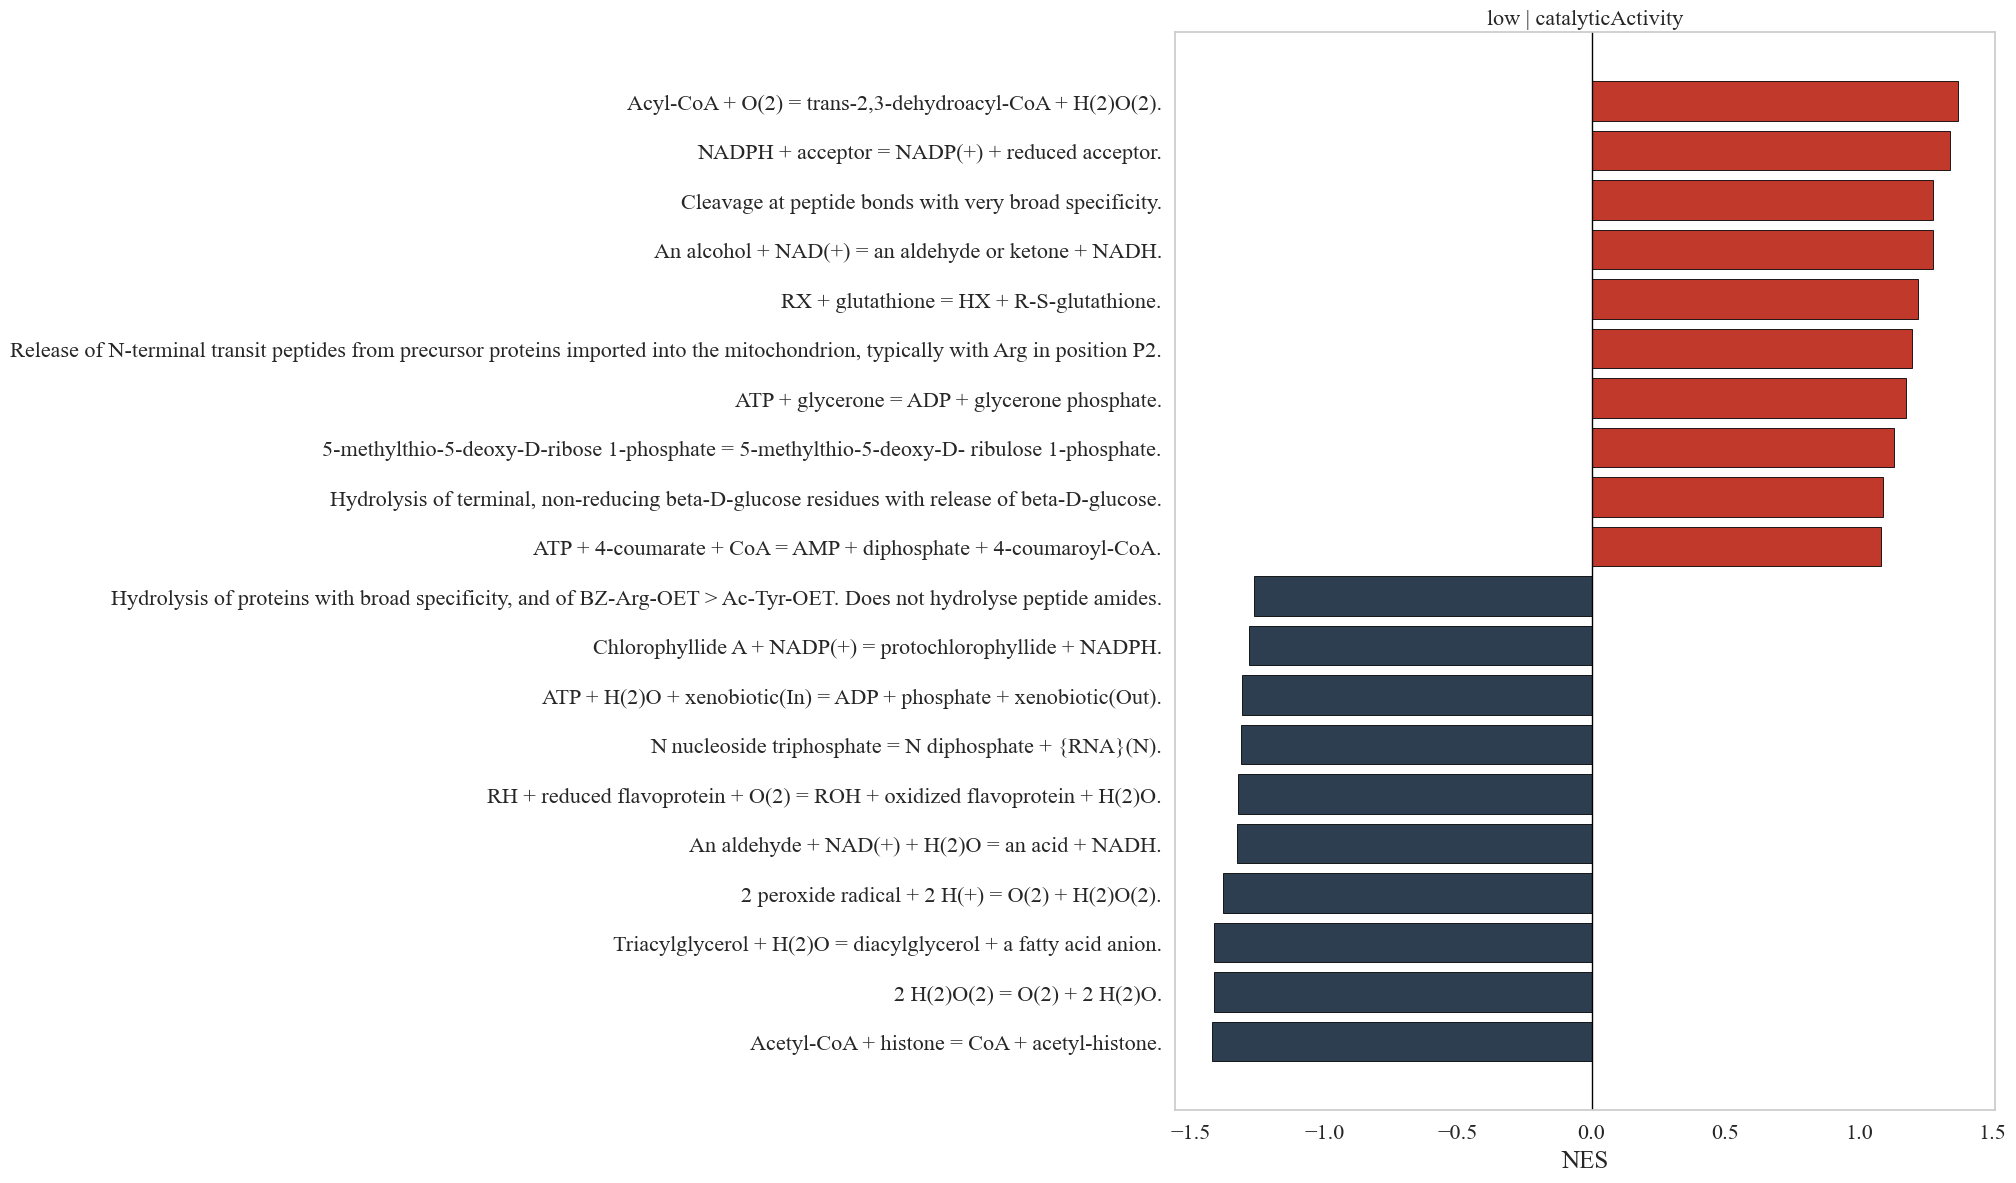

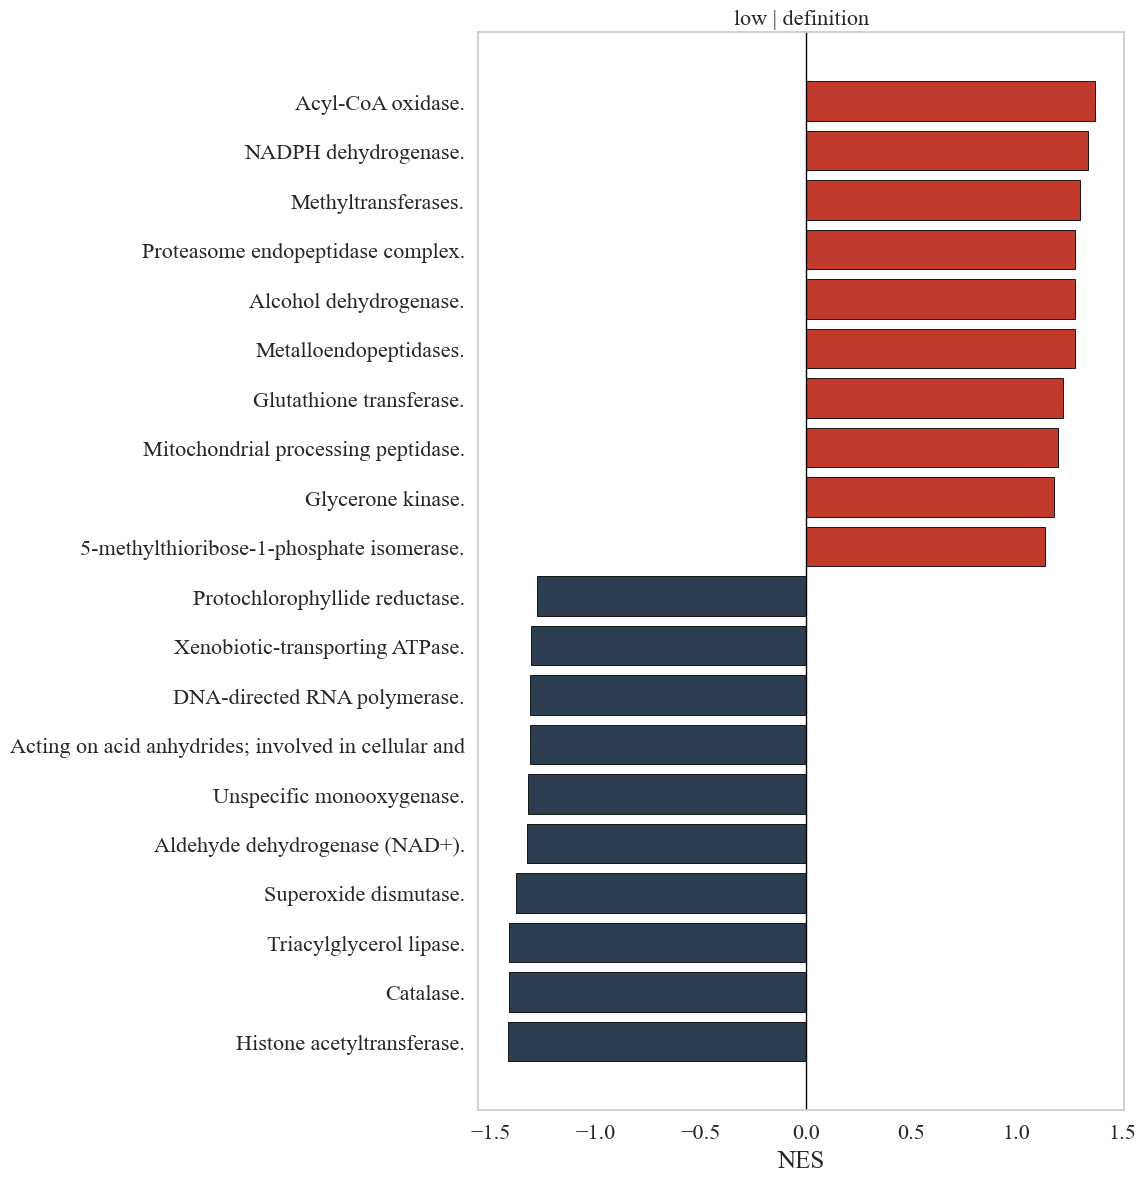

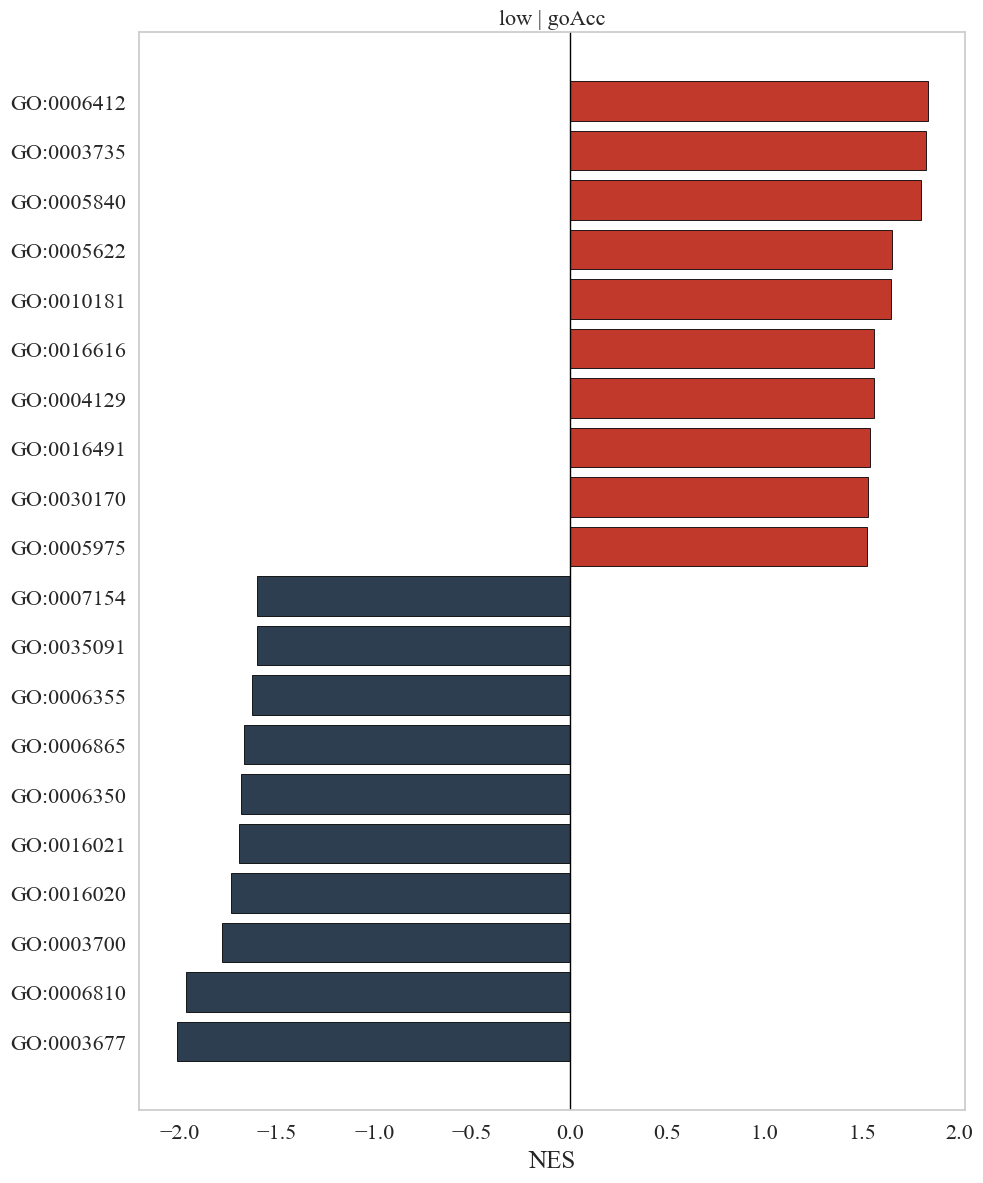

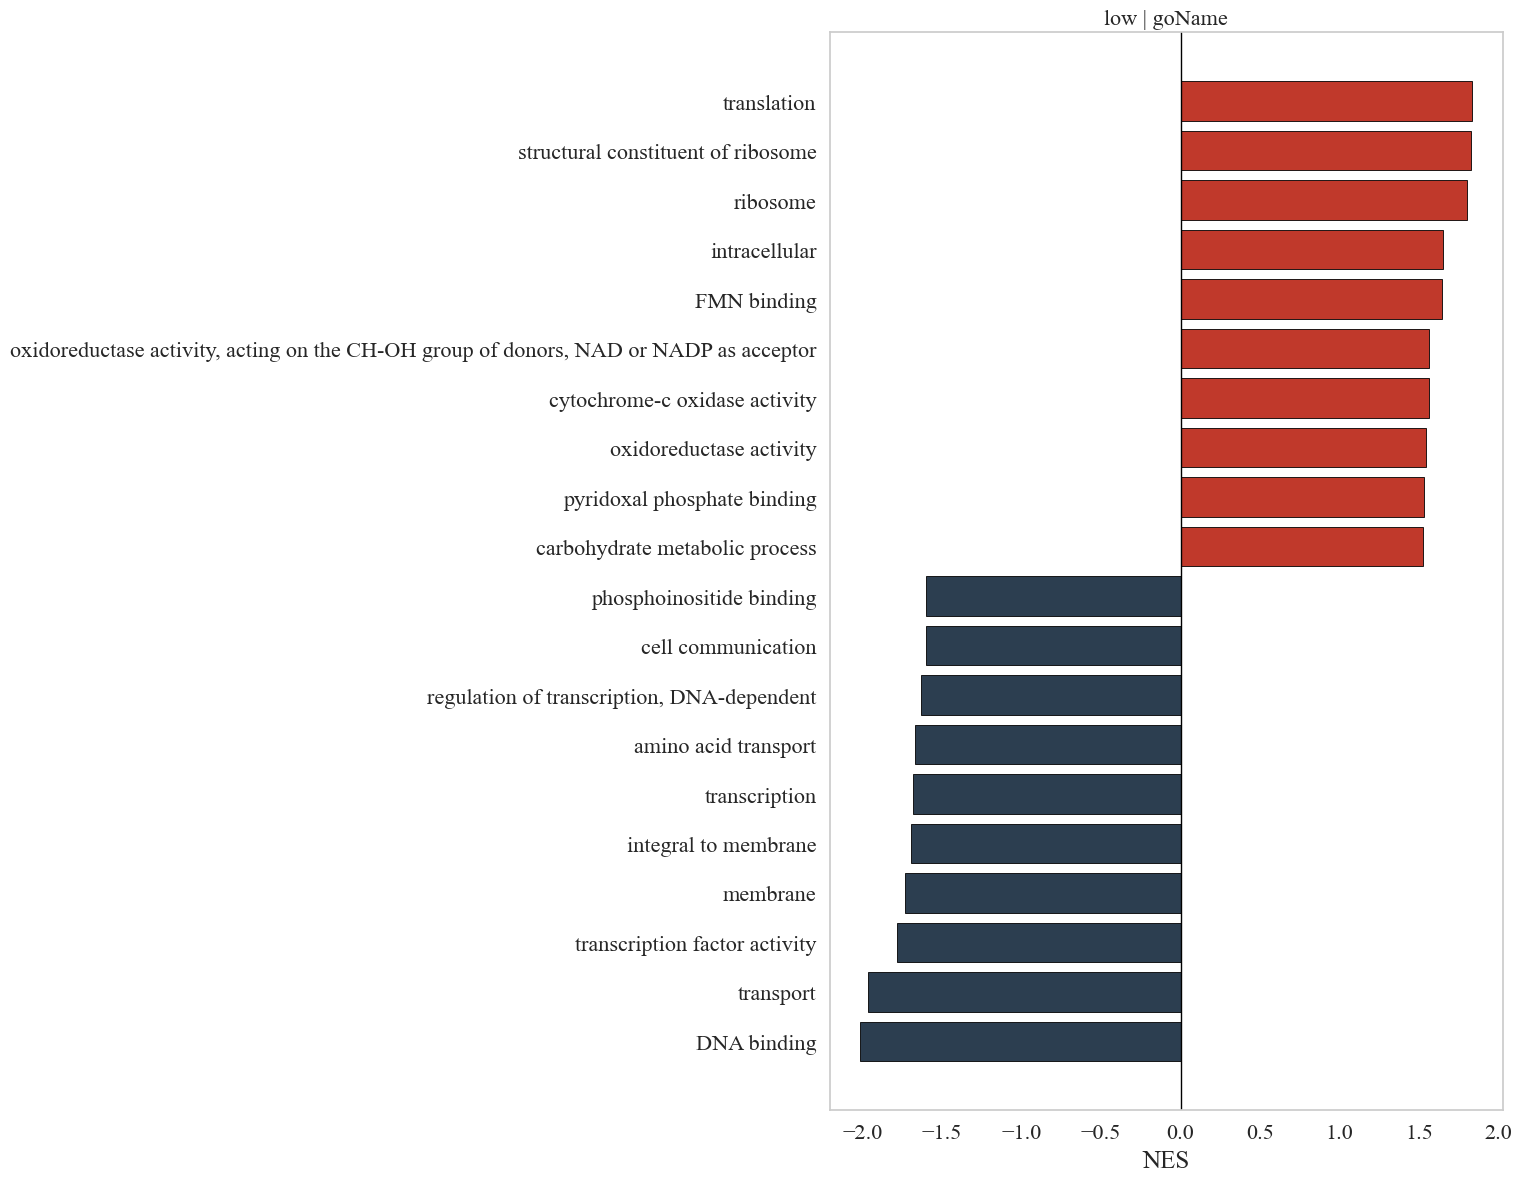

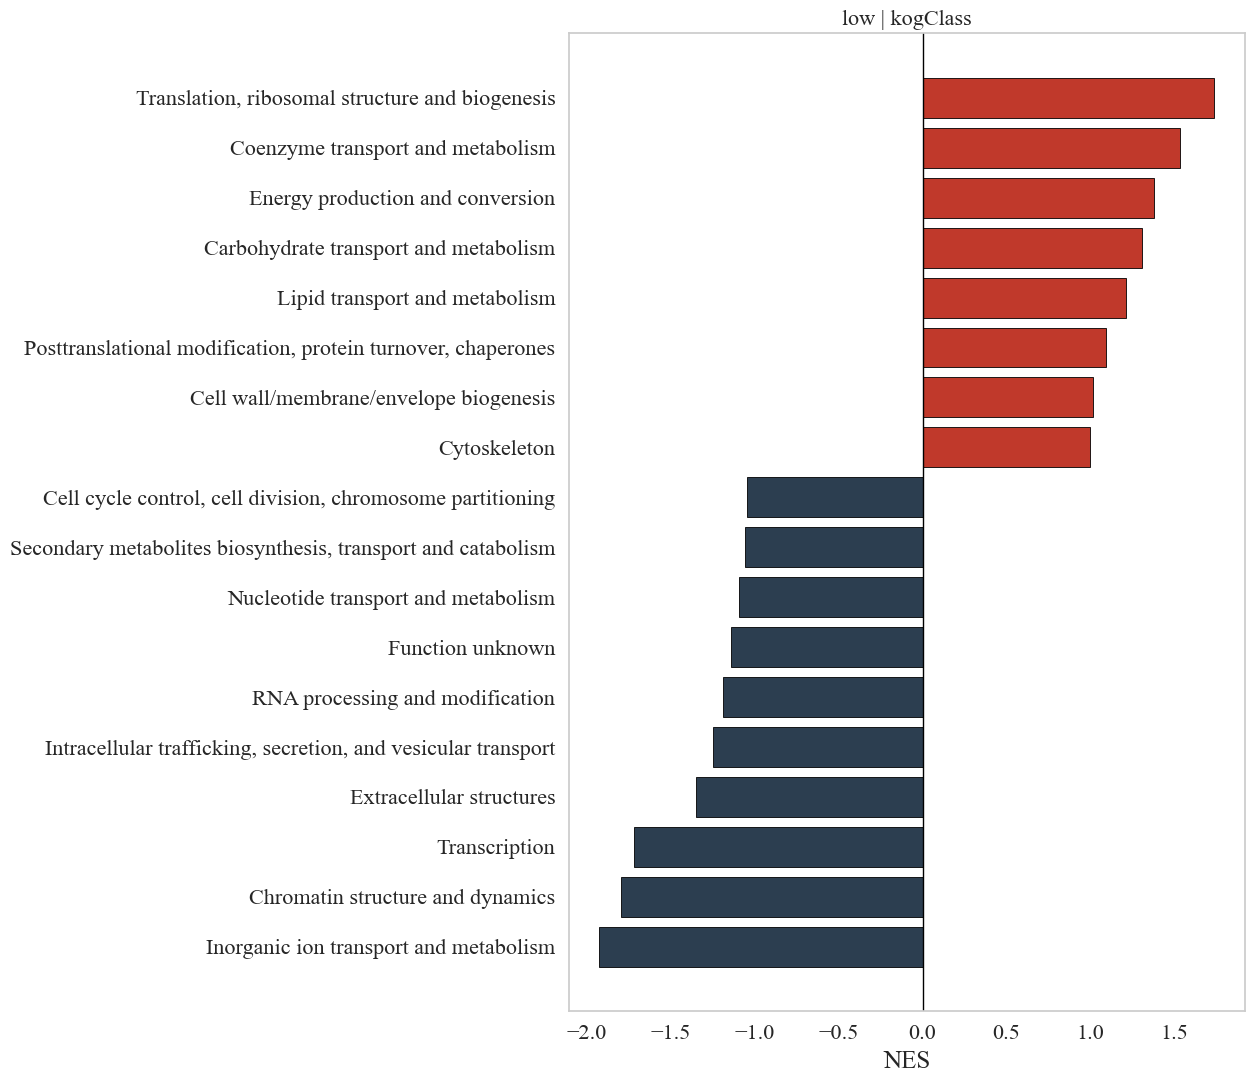

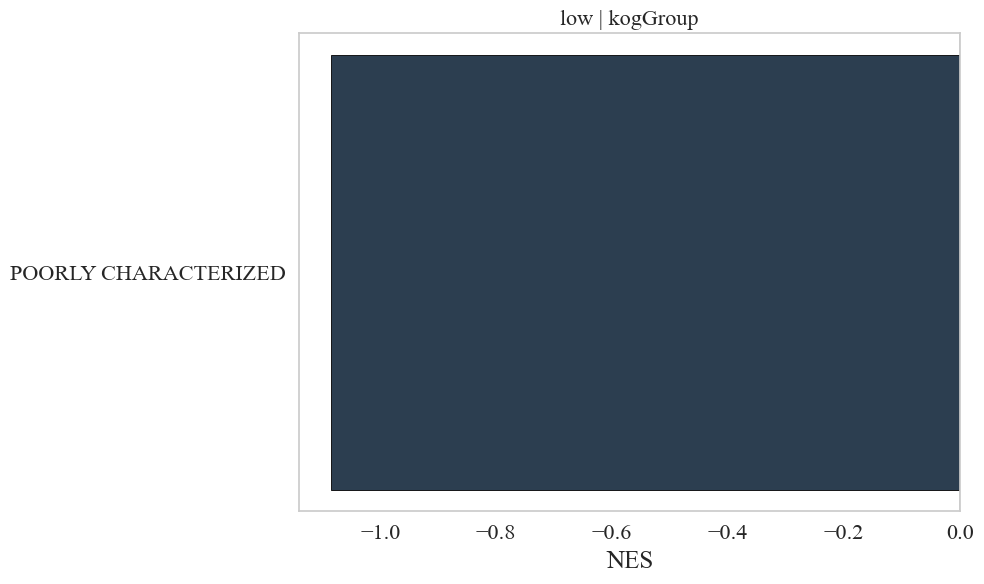

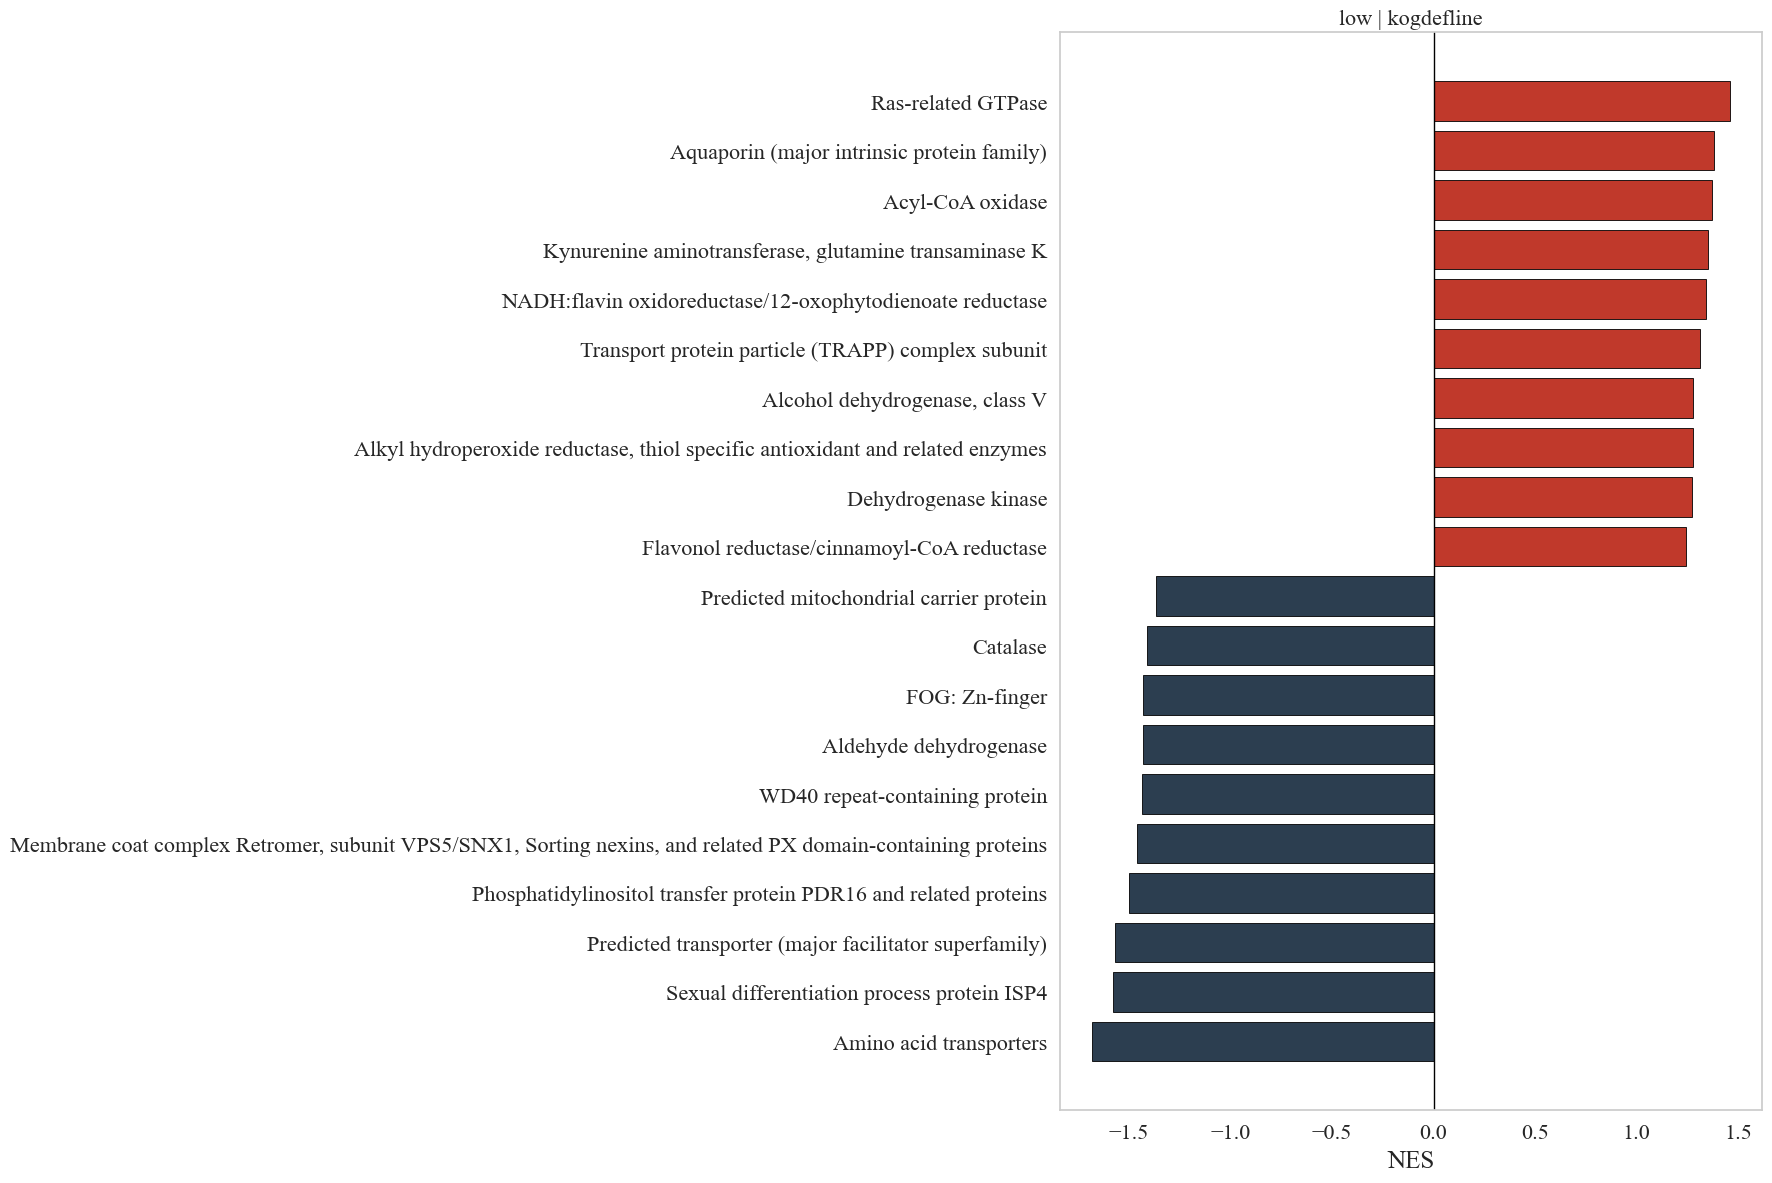

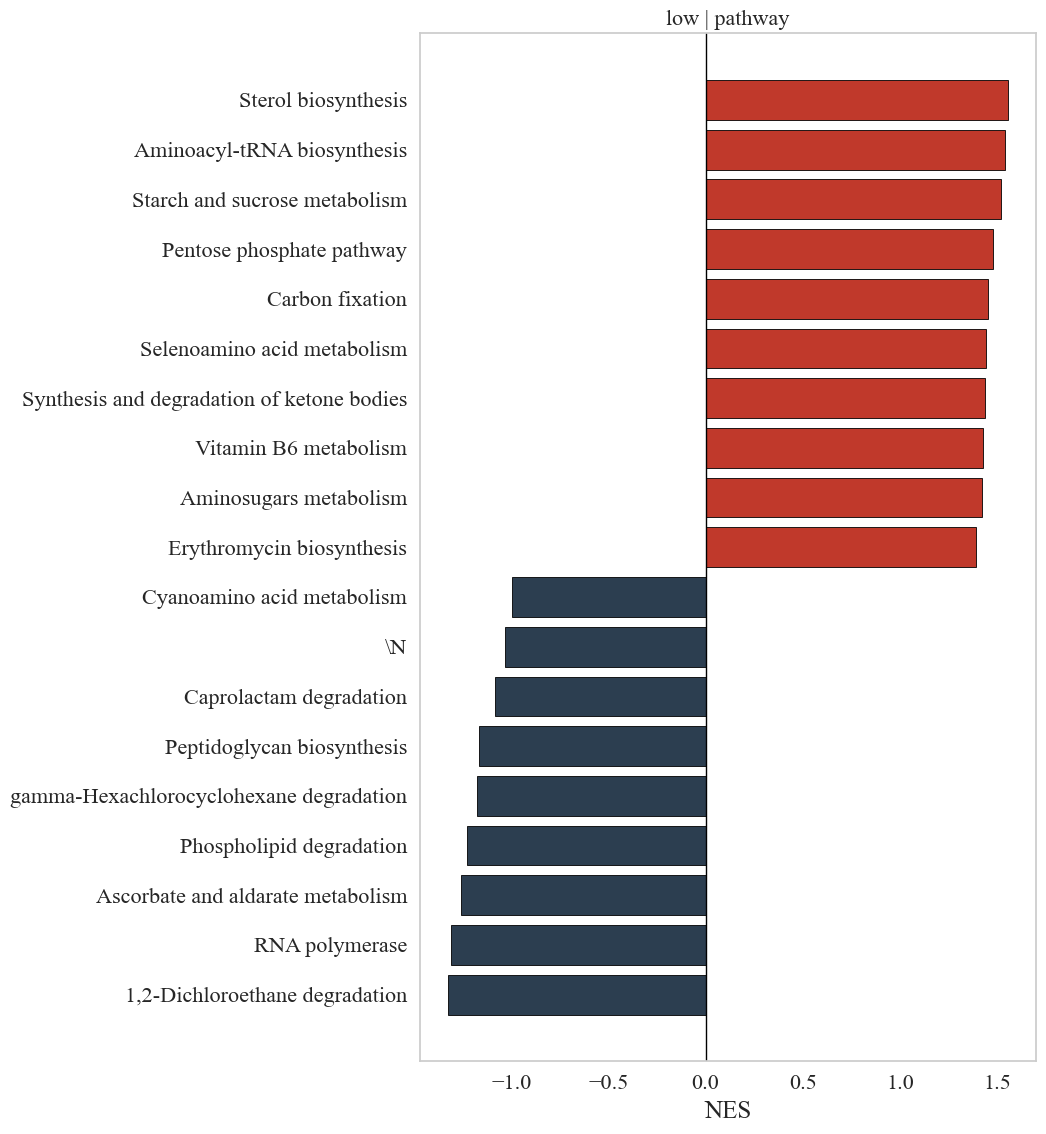

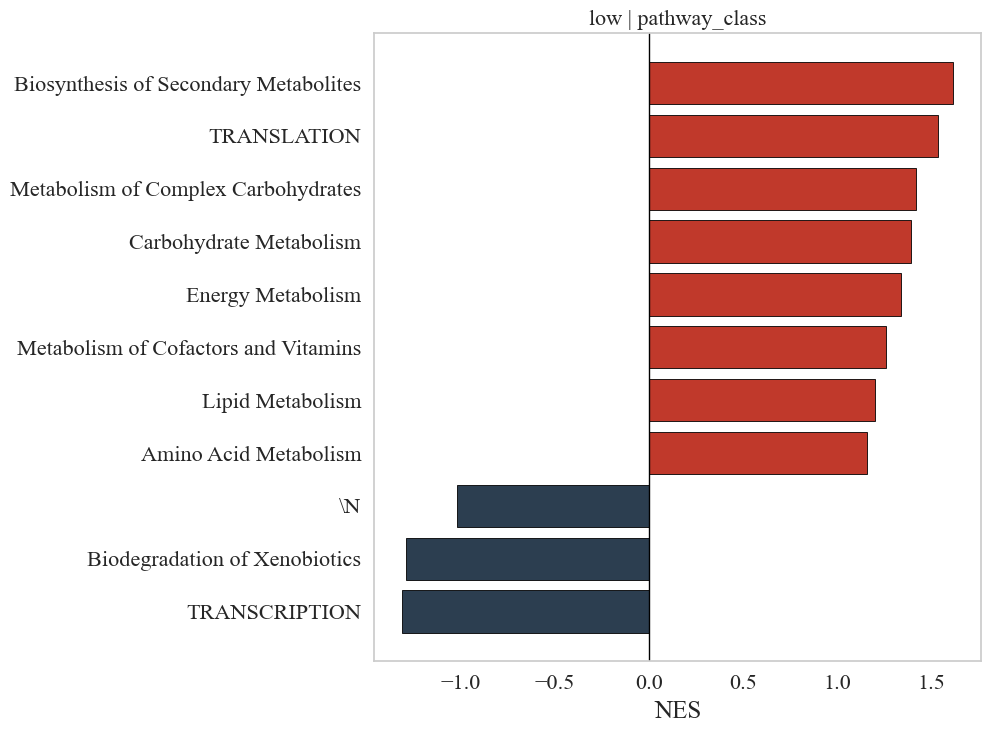

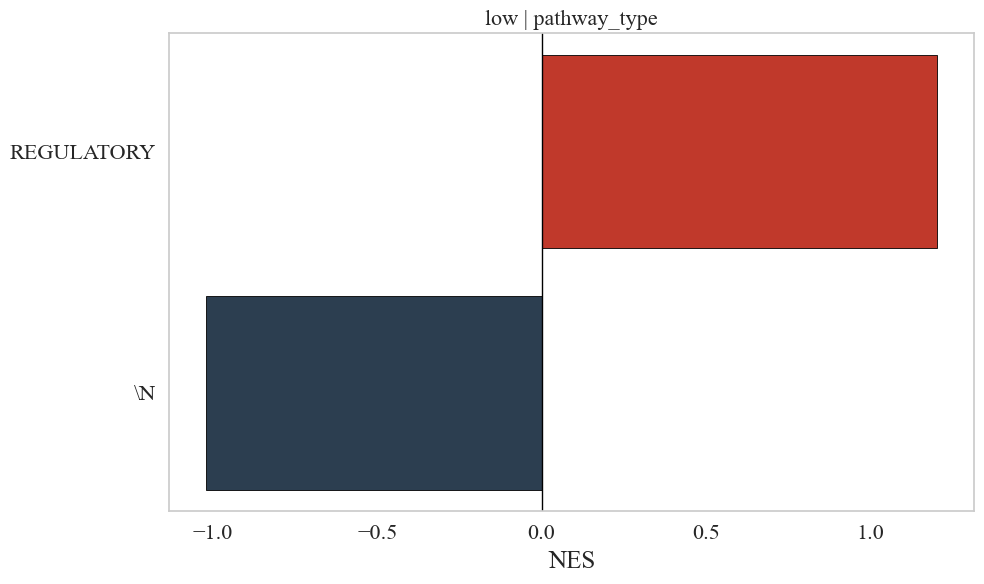

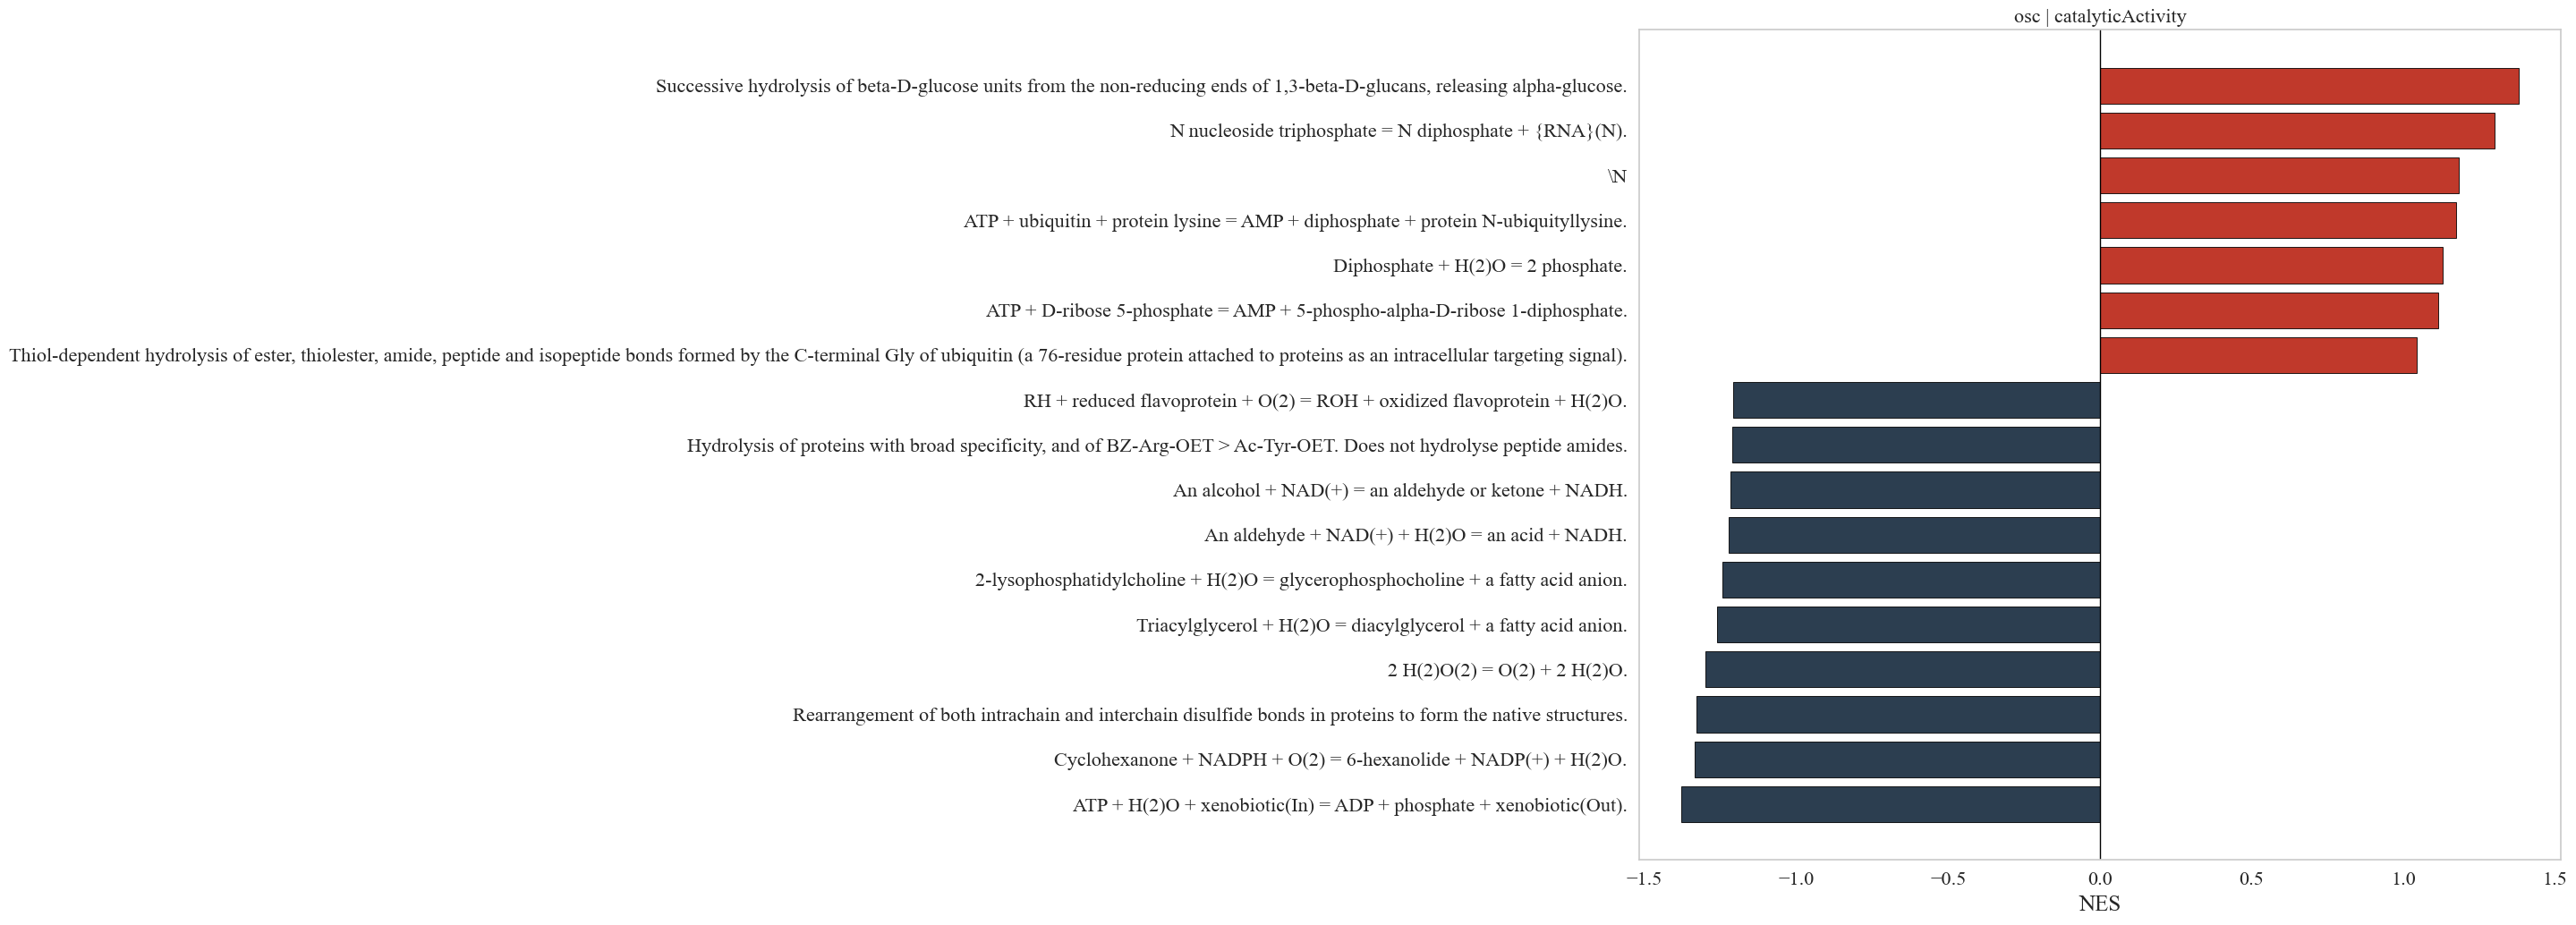

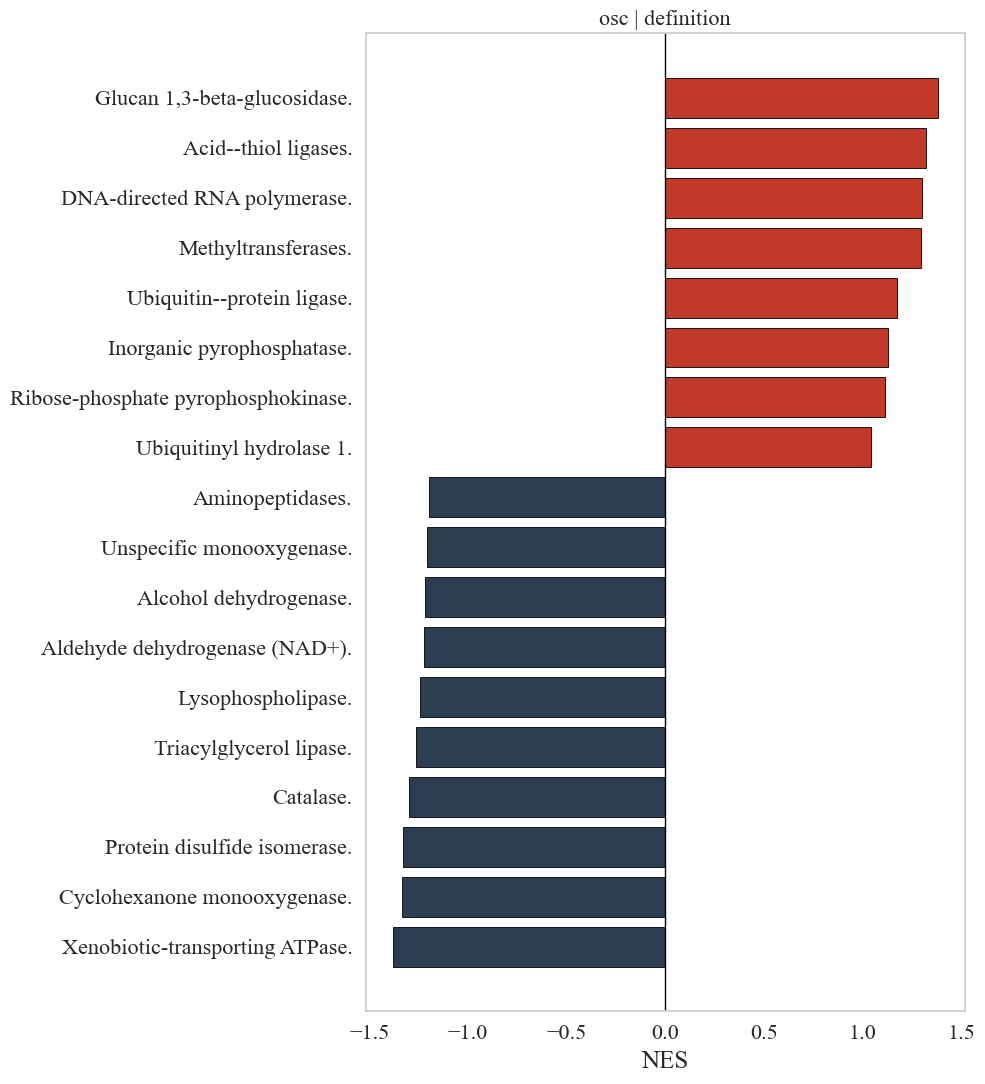

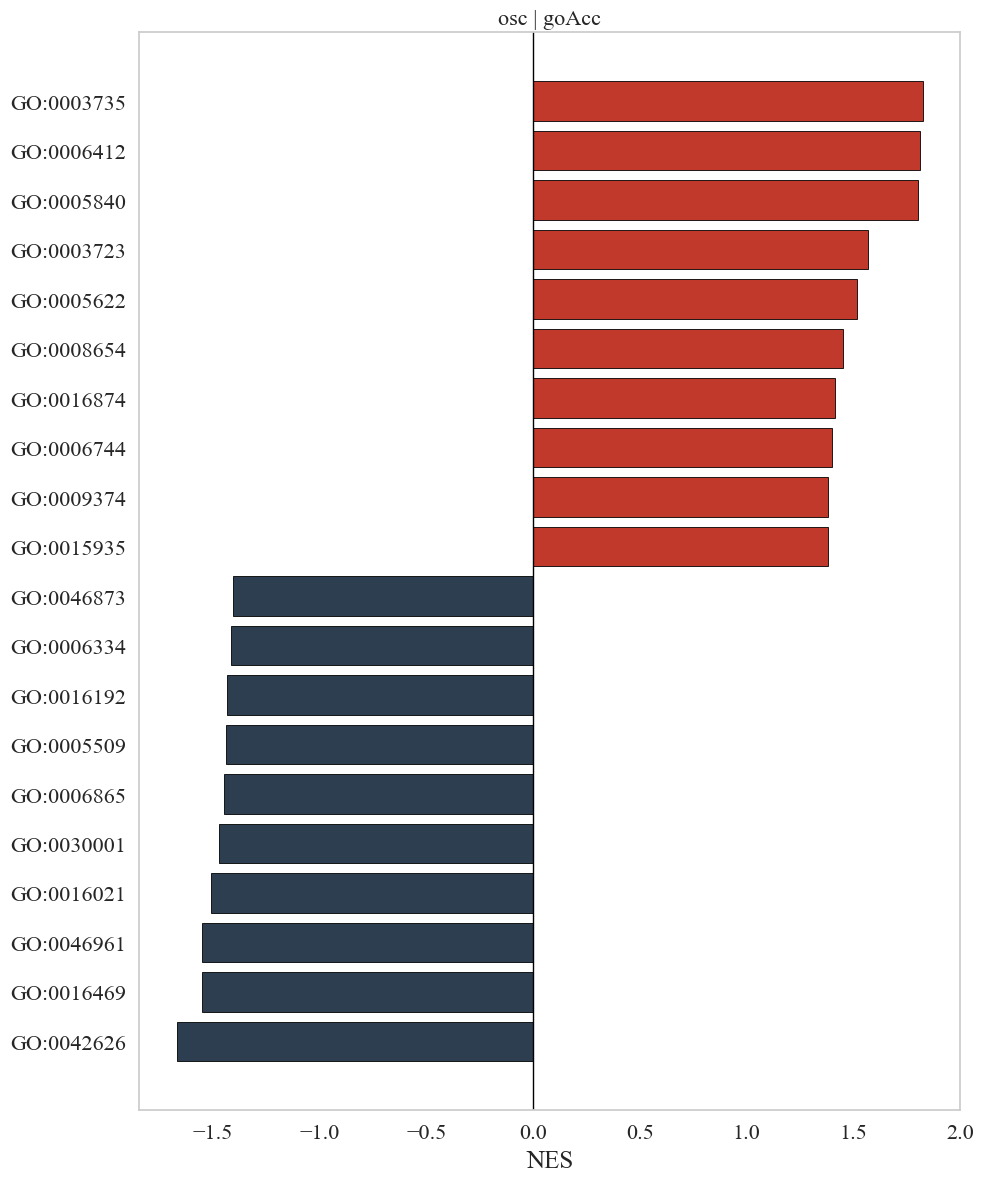

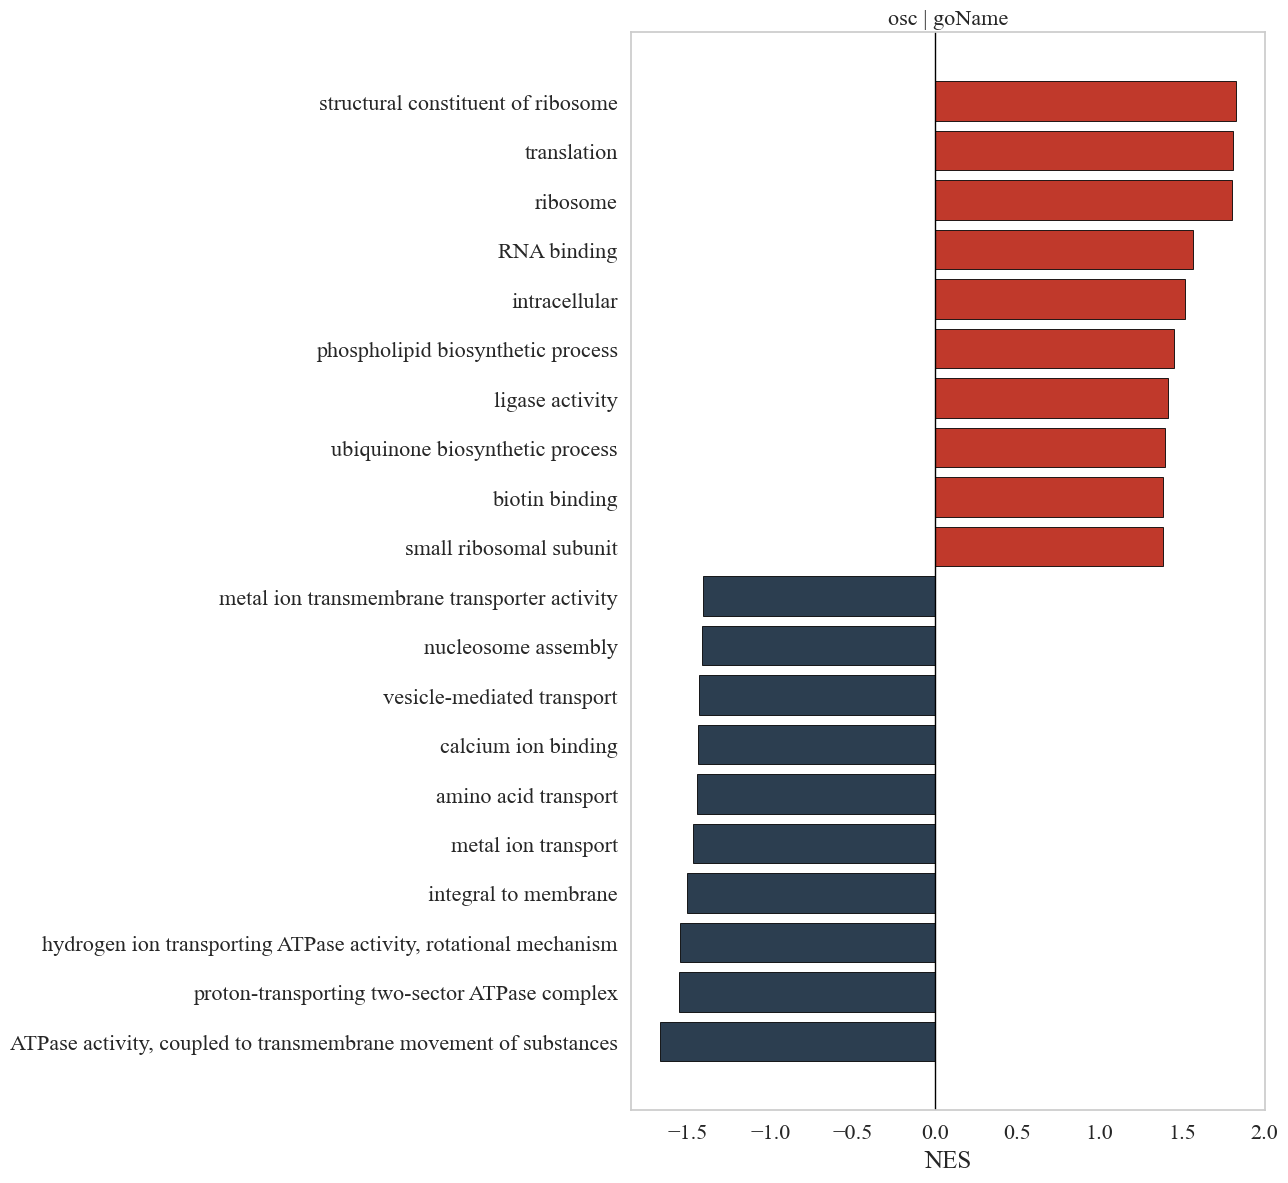

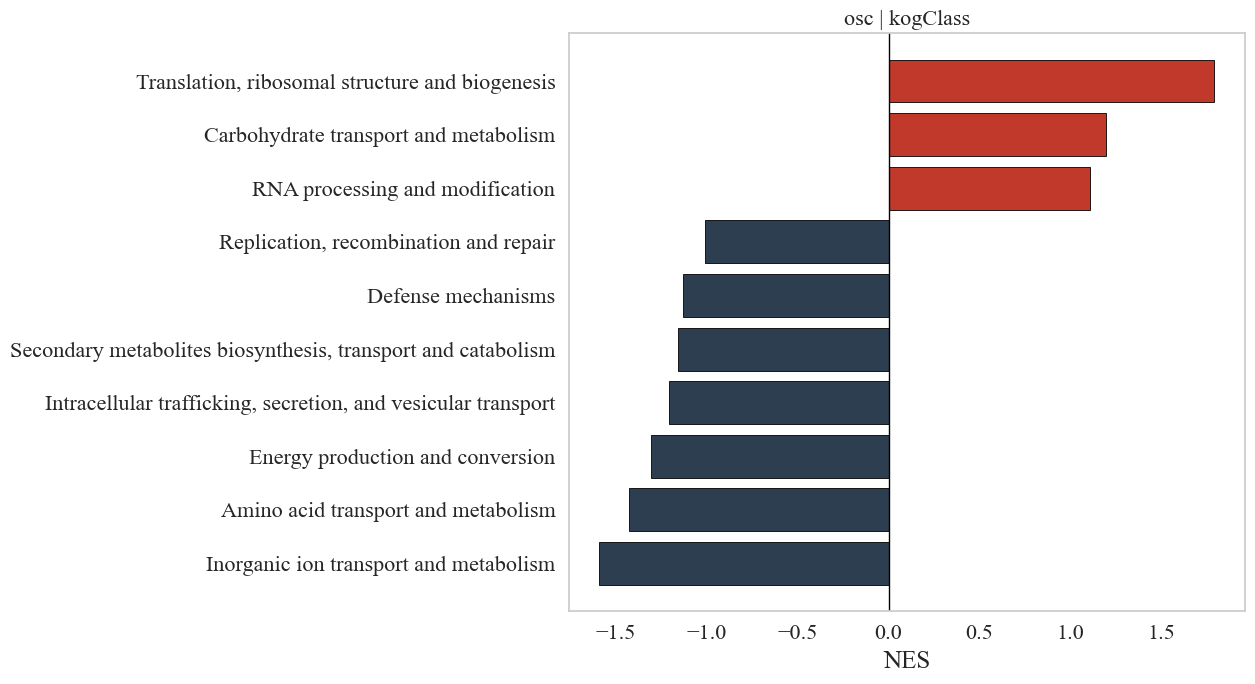

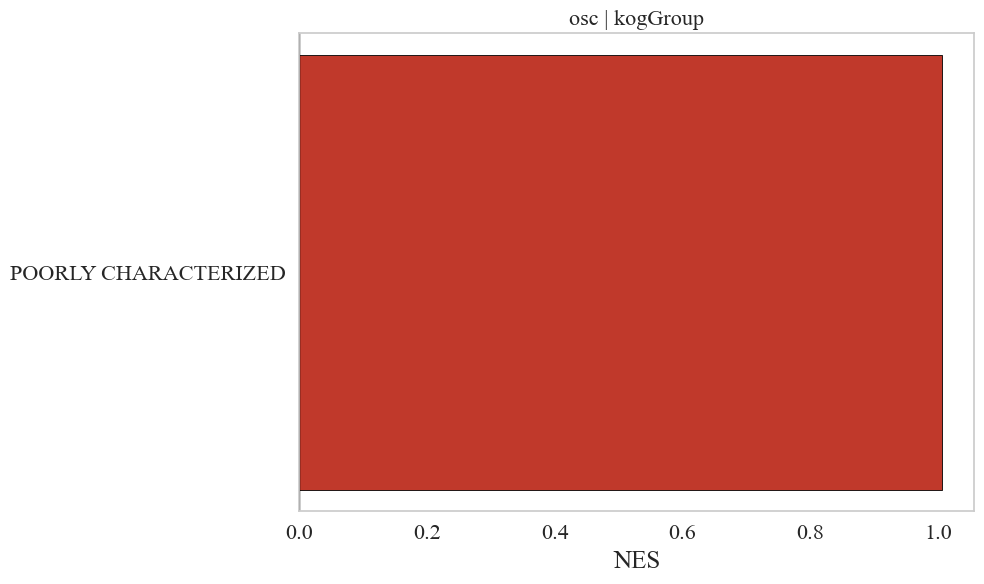

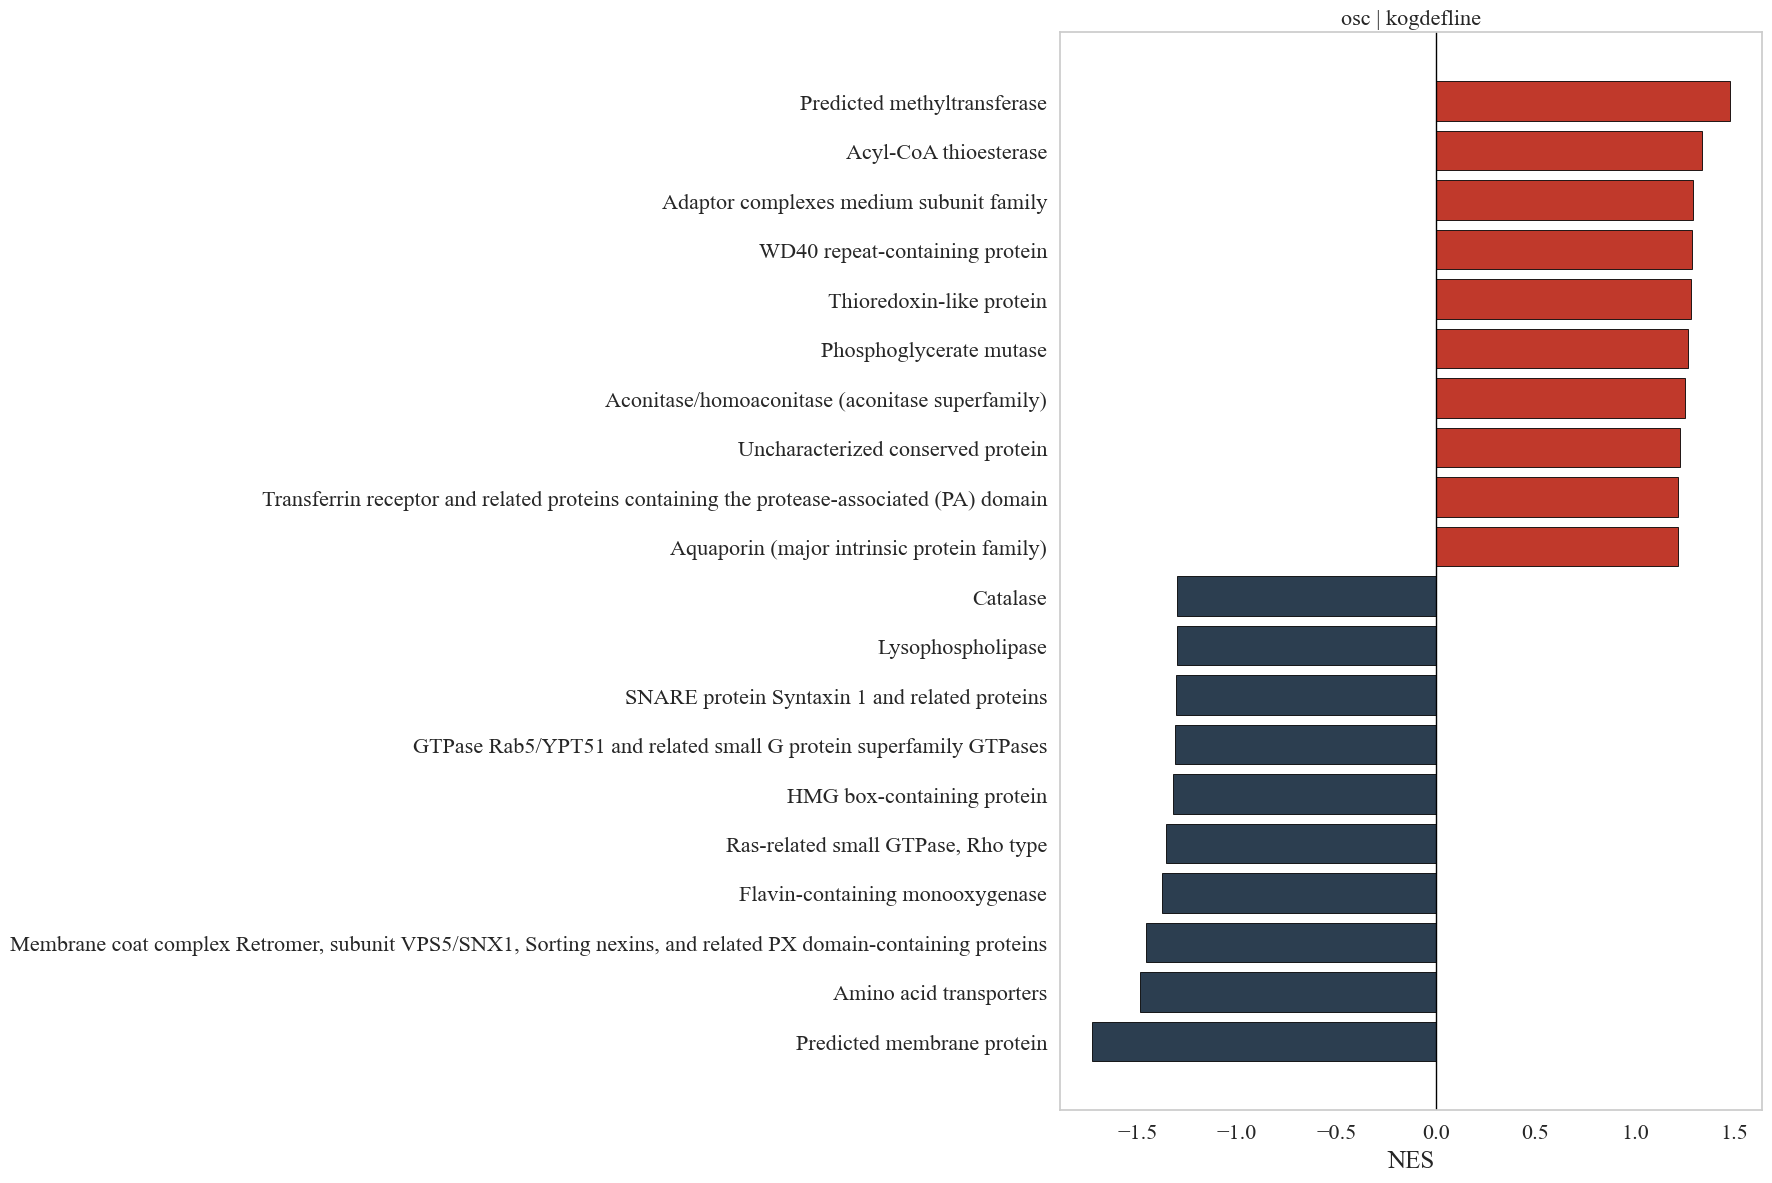

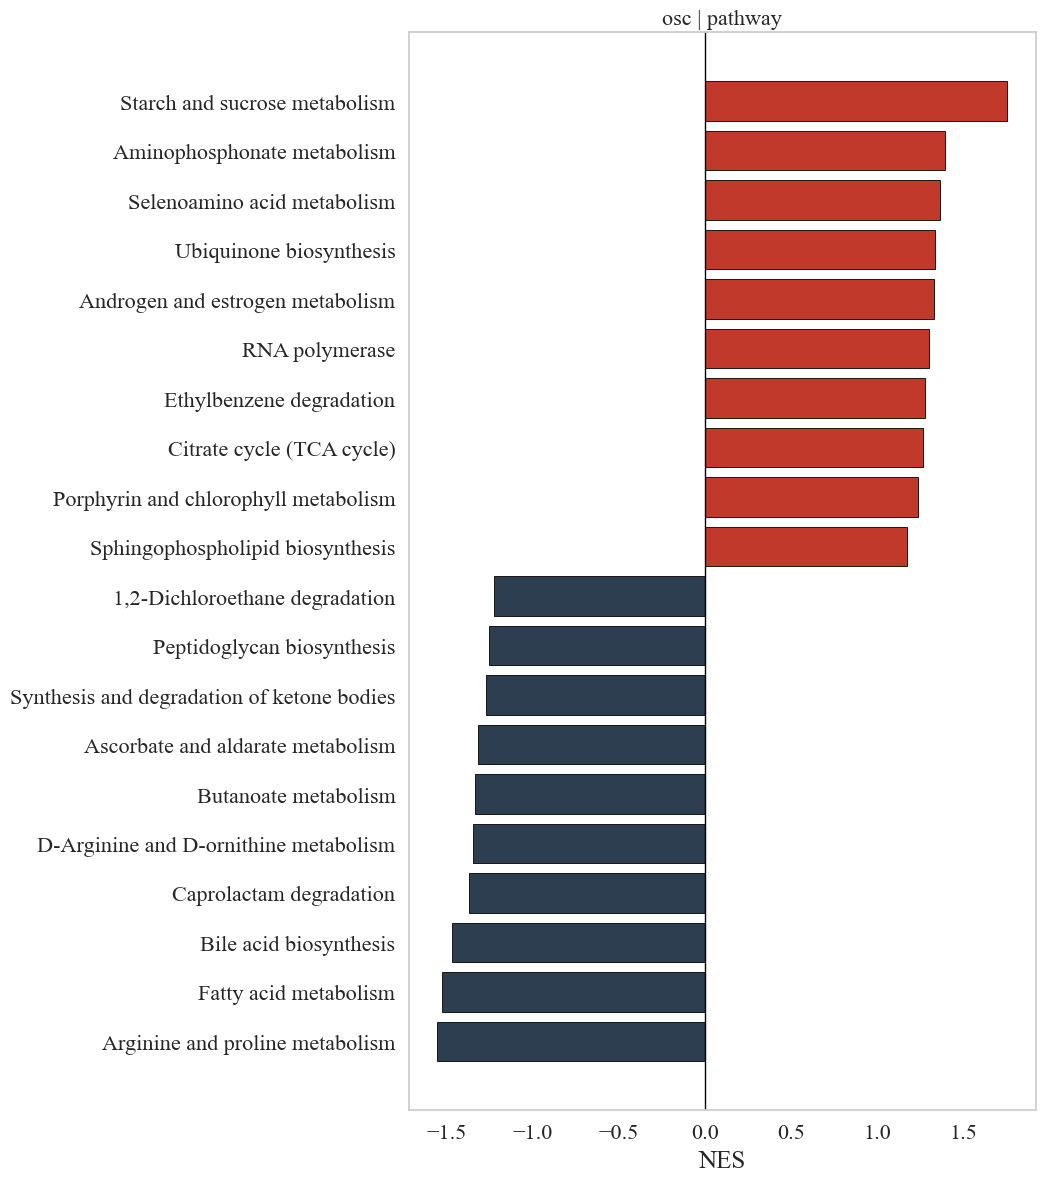

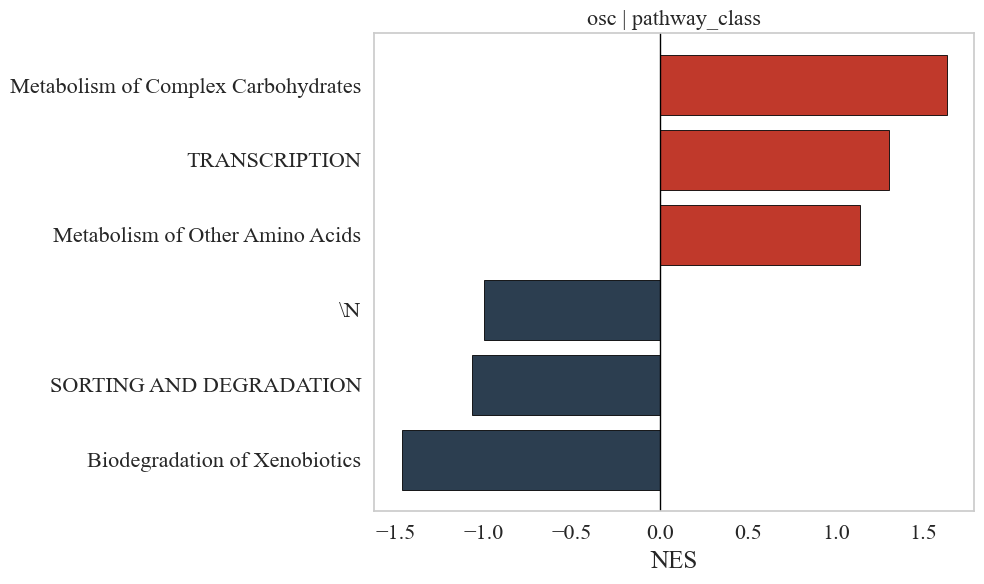

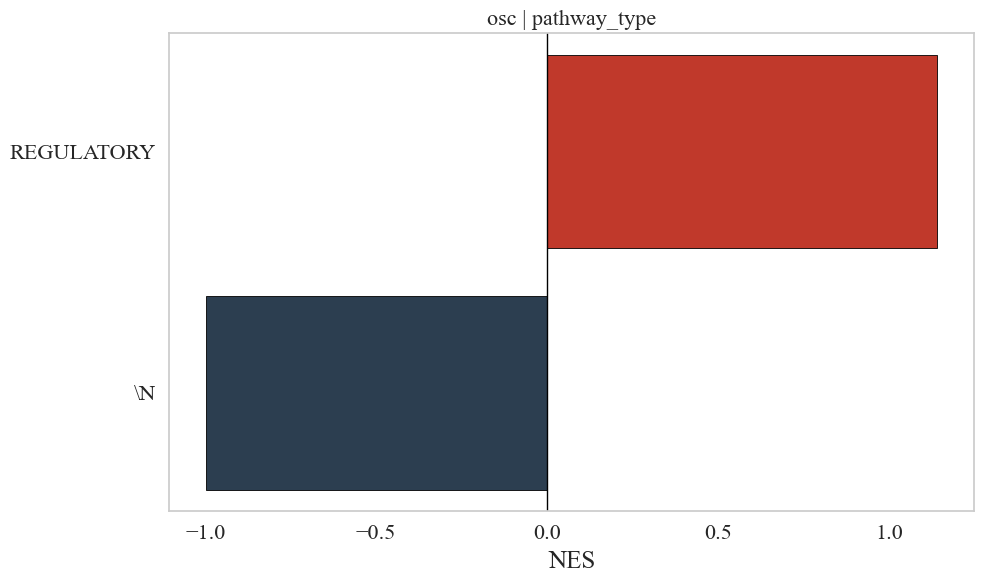


Saved 20 figures to gsea_figures/


In [88]:
plot_all_gsea_terms(gsea_summary, top_n=10, pval_cutoff=0.5)